# Double Pendulum Small Vibrations CUED IB Mechanics

The following code is mostly completed for you: press 'shift-enter' in each cell to run the code starting at the top. You will get some errors part of the way through and this is where you need to fill in the gaps.



Import standard set of modules for scientific computing and plotting [ALREADY COMPLETE]:

In [4]:
import numpy as np
import scipy as sp
import math
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
matplotlib.rcParams.update({'font.size': 18,'font.family':'serif'})

This cell loads the experimental data on the examples sheet for experiments 1, 2 and 3.
The final format for each experiment is an array of four items, ["name of experiment", timepoints, alphas, betas],
where timepoints is a list of the time points, and alphas/betas are lists of the alpha/beta angles (in degrees) at each time point.
[ALREADY COMPLETE]:

In [5]:
# This cell loads the experimental data for experiments 1, 2 and 3 on the examples sheet.


time_exp_1 = np.array([0.,0.0111111,0.0222222,0.0333333,0.0444444,0.0555556,0.0666667,0.0777778,0.0888889,0.1,0.111111,0.122222,0.133333,0.144444,0.155556,0.166667,0.177778,0.188889,0.2,0.211111,0.222222,0.233333,0.244444,0.255556,0.266667,0.277778,0.288889,0.3,0.311111,0.322222,0.333333,0.344444,0.355556,0.366667,0.377778,0.388889,0.4,0.411111,0.422222,0.433333,0.444444,0.455556,0.466667,0.477778,0.488889,0.5,0.511111,0.522222,0.533333,0.544444,0.555556,0.566667,0.577778,0.588889,0.6,0.611111,0.622222,0.633333,0.644444,0.655556,0.666667,0.677778,0.688889,0.7,0.711111,0.722222,0.733333,0.744444,0.755556,0.766667,0.777778,0.788889,0.8,0.811111,0.822222,0.833333,0.844444,0.855556,0.866667,0.877778,0.888889,0.9,0.911111,0.922222,0.933333,0.944444,0.955556,0.966667,0.977778,0.988889,1.,1.01111,1.02222,1.03333,1.04444,1.05556,1.06667,1.07778,1.08889,1.1,1.11111,1.12222,1.13333,1.14444,1.15556,1.16667,1.17778,1.18889,1.2,1.21111,1.22222,1.23333,1.24444,1.25556,1.26667,1.27778,1.28889,1.3,1.31111,1.32222,1.33333,1.34444,1.35556,1.36667,1.37778,1.38889,1.4,1.41111,1.42222,1.43333,1.44444,1.45556,1.46667,1.47778,1.48889,1.5,1.51111,1.52222,1.53333,1.54444,1.55556,1.56667,1.57778,1.58889,1.6,1.61111,1.62222,1.63333,1.64444,1.65556,1.66667,1.67778,1.68889,1.7,1.71111,1.72222,1.73333,1.74444,1.75556,1.76667,1.77778,1.78889,1.8,1.81111,1.82222,1.83333,1.84444,1.85556,1.86667,1.87778,1.88889,1.9,1.91111,1.92222,1.93333,1.94444,1.95556,1.96667,1.97778,1.98889,2.,2.01111,2.02222,2.03333,2.04444,2.05556,2.06667,2.07778,2.08889,2.1,2.11111,2.12222,2.13333,2.14444,2.15556,2.16667,2.17778,2.18889,2.2,2.21111,2.22222,2.23333,2.24444,2.25556,2.26667,2.27778,2.28889,2.3,2.31111,2.32222,2.33333,2.34444,2.35556,2.36667,2.37778,2.38889,2.4,2.41111,2.42222,2.43333,2.44444,2.45556,2.46667,2.47778,2.48889,2.5,2.51111,2.52222,2.53333,2.54444,2.55556,2.56667,2.57778,2.58889,2.6,2.61111,2.62222,2.63333,2.64444,2.65556,2.66667,2.67778,2.68889,2.7,2.71111,2.72222,2.73333,2.74444,2.75556,2.76667,2.77778,2.78889,2.8,2.81111,2.82222,2.83333,2.84444,2.85556,2.86667,2.87778,2.88889,2.9,2.91111,2.92222,2.93333,2.94444,2.95556,2.96667,2.97778,2.98889,3.,3.01111,3.02222,3.03333,3.04444,3.05556,3.06667,3.07778,3.08889,3.1,3.11111,3.12222,3.13333,3.14444,3.15556,3.16667,3.17778,3.18889,3.2,3.21111,3.22222,3.23333,3.24444,3.25556,3.26667,3.27778,3.28889,3.3,3.31111,3.32222,3.33333,3.34444,3.35556,3.36667,3.37778,3.38889,3.4,3.41111,3.42222,3.43333,3.44444,3.45556,3.46667,3.47778,3.48889,3.5,3.51111,3.52222,3.53333,3.54444,3.55556,3.56667,3.57778,3.58889,3.6,3.61111,3.62222,3.63333,3.64444,3.65556,3.66667,3.67778,3.68889,3.7,3.71111,3.72222,3.73333,3.74444,3.75556,3.76667,3.77778,3.78889,3.8,3.81111,3.82222,3.83333,3.84444,3.85556,3.86667,3.87778,3.88889,3.9,3.91111,3.92222,3.93333,3.94444,3.95556,3.96667,3.97778,3.98889,4.,4.01111,4.02222,4.03333,4.04444,4.05556,4.06667,4.07778,4.08889,4.1,4.11111,4.12222,4.13333,4.14444,4.15556,4.16667,4.17778,4.18889,4.2,4.21111,4.22222,4.23333,4.24444,4.25556,4.26667,4.27778,4.28889,4.3,4.31111,4.32222,4.33333,4.34444,4.35556,4.36667,4.37778,4.38889,4.4,4.41111,4.42222,4.43333,4.44444,4.45556,4.46667,4.47778,4.48889,4.5,4.51111,4.52222,4.53333,4.54444,4.55556,4.56667,4.57778,4.58889,4.6,4.61111,4.62222,4.63333,4.64444,4.65556,4.66667,4.67778,4.68889,4.7,4.71111,4.72222,4.73333,4.74444,4.75556,4.76667,4.77778,4.78889,4.8,4.81111,4.82222,4.83333,4.84444,4.85556,4.86667,4.87778,4.88889,4.9,4.91111,4.92222,4.93333,4.94444,4.95556,4.96667,4.97778,4.98889,5.])
alpha_exp_1 =  np.array([2.84239,3.20602,3.61468,3.93772,4.23296,4.55116,4.77848,5.01914,5.21669,5.38611,5.47613,5.55316,5.59925,5.58964,5.5774,5.51673,5.44202,5.33507,5.17329,4.96554,4.7289,4.52102,4.2367,3.95266,3.63683,3.25607,2.92872,2.51185,2.17757,1.72483,1.30879,0.903022,0.418937,0.0190558,-0.469041,-0.887936,-1.34795,-1.78742,-2.17515,-2.64991,-3.00614,-3.45486,-3.79017,-4.17119,-4.50009,-4.8255,-5.1193,-5.35238,-5.60052,-5.84922,-5.99368,-6.09941,-6.23897,-6.31944,-6.36028,-6.37474,-6.36095,-6.29013,-6.19568,-6.08017,-5.96155,-5.79863,-5.53698,-5.2934,-5.08623,-4.75185,-4.43148,-4.11817,-3.73339,-3.39774,-2.9505,-2.58494,-2.13993,-1.7189,-1.29396,-0.838676,-0.406699,0.0733716,0.498881,0.920274,1.35798,1.75499,2.1982,2.52536,2.93412,3.24909,3.6123,3.89975,4.12914,4.40215,4.63579,4.77098,4.92141,5.06997,5.16144,5.20755,5.21228,5.20407,5.1371,5.03411,4.90306,4.74294,4.60559,4.38324,4.1144,3.89503,3.62031,3.26651,2.97031,2.58502,2.26556,1.83656,1.486,1.04225,0.68145,0.215392,-0.174785,-0.598854,-0.999069,-1.39385,-1.85583,-2.20035,-2.62307,-2.95018,-3.34975,-3.65321,-3.99374,-4.31319,-4.57234,-4.81017,-5.08385,-5.23241,-5.39426,-5.55721,-5.68343,-5.78259,-5.83884,-5.86254,-5.86184,-5.83359,-5.73744,-5.63368,-5.50642,-5.32865,-5.20364,-5.00047,-4.75792,-4.5055,-4.2835,-3.97203,-3.65095,-3.35863,-2.97339,-2.67224,-2.27369,-1.93716,-1.49673,-1.16482,-0.735409,-0.386124,0.058546,0.410685,0.846199,1.16542,1.56912,1.88315,2.28274,2.55289,2.89498,3.16803,3.40521,3.69508,3.90969,4.07831,4.26653,4.41356,4.52357,4.61911,4.65683,4.66638,4.65569,4.6199,4.53414,4.42026,4.28925,4.09924,3.94248,3.74361,3.47761,3.23418,2.97129,2.64086,2.36464,2.01504,1.65886,1.31187,0.933384,0.556543,0.174485,-0.214163,-0.58916,-0.988536,-1.35008,-1.75087,-2.10545,-2.47018,-2.82823,-3.14927,-3.48274,-3.75337,-4.04398,-4.30922,-4.51367,-4.71651,-4.91365,-5.08945,-5.19725,-5.26153,-5.3268,-5.37068,-5.3953,-5.35273,-5.30623,-5.24955,-5.17876,-5.10034,-4.90993,-4.73419,-4.53763,-4.34638,-4.10688,-3.82424,-3.57967,-3.29829,-2.94849,-2.69233,-2.32424,-2.02051,-1.64174,-1.32084,-0.947102,-0.591966,-0.243442,0.12893,0.453452,0.831021,1.11327,1.4742,1.76006,2.08725,2.37038,2.59433,2.8839,3.12303,3.27668,3.4724,3.6685,3.79511,3.91257,3.97372,4.03551,4.0496,4.04885,4.03368,3.99673,3.95109,3.85142,3.73291,3.59108,3.38595,3.22116,3.04204,2.78115,2.51633,2.29843,2.00114,1.68993,1.42125,1.06171,0.771002,0.396645,0.0928874,-0.274732,-0.598356,-0.913678,-1.30874,-1.59947,-1.97265,-2.25409,-2.59443,-2.85848,-3.13752,-3.4394,-3.65654,-3.8887,-4.13534,-4.30941,-4.46257,-4.59191,-4.69537,-4.80522,-4.89515,-4.91408,-4.95005,-4.93329,-4.90446,-4.8147,-4.71925,-4.59634,-4.47411,-4.33659,-4.17483,-3.94906,-3.73707,-3.51087,-3.25478,-2.97366,-2.74573,-2.40569,-2.10858,-1.82417,-1.47351,-1.18703,-0.83636,-0.532499,-0.193802,0.141162,0.442233,0.791399,1.03184,1.3731,1.64727,1.88113,2.18279,2.40829,2.58388,2.81918,3.0029,3.1647,3.25671,3.35625,3.46641,3.57268,3.59347,3.62667,3.62382,3.59066,3.50686,3.4179,3.31232,3.21516,3.10431,2.94896,2.74159,2.52893,2.36431,2.14089,1.8696,1.63323,1.36895,1.05844,0.82204,0.515805,0.203403,-0.0606755,-0.396341,-0.65411,-0.980095,-1.29366,-1.5513,-1.87307,-2.1059,-2.3997,-2.67945,-2.8757,-3.10703,-3.3588,-3.54207,-3.6865,-3.85524,-4.00836,-4.13966,-4.23903,-4.30907,-4.36064,-4.40758,-4.39791,-4.39374,-4.34712,-4.28822,-4.22308,-4.12518,-4.0023,-3.83675,-3.68881,-3.53648,-3.36319,-3.13988,-2.91079,-2.6977,-2.44558,-2.15369,-1.94521,-1.64015,-1.36304,-1.10659,-0.797134,-0.542362,-0.227834,0.0775441,0.315059,0.61582,0.904095,1.13237,1.42084,1.64647,1.82768,2.08166,2.29198,2.44239,2.59309,2.73412,2.88553,2.98994,3.06012,3.14049,3.15418,3.17027,3.17285,3.13521,3.08694,3.012,2.92395,2.79594,2.65798,2.49246,2.38658,2.20468,1.98061,1.76109,1.58308,1.34764,1.06638,0.865457,0.613884,0.312549,0.0933587,-0.173047,-0.48746,-0.714045,-0.996153])
beta_exp_1 =  np.array([7.20638,7.95872,8.72563,9.42912,10.091,10.8186,11.3356,11.7379,12.1457,12.5507,12.8012,13.156,13.3043,13.3723,13.3976,13.2419,12.9953,12.8281,12.526,12.1039,11.8284,11.0664,10.4626,9.87808,9.17968,8.31489,7.32768,6.49064,5.42393,4.60249,3.51602,2.4444,1.43114,0.335599,-0.614528,-1.71709,-2.71697,-3.79976,-4.82543,-5.66728,-6.63666,-7.42972,-8.38465,-9.19895,-9.91828,-10.4428,-10.9802,-11.6568,-11.9819,-12.3874,-12.63,-13.0573,-13.1335,-13.2204,-13.1969,-13.123,-12.9585,-12.6654,-12.3652,-12.0777,-11.4829,-10.9361,-10.4651,-9.90404,-8.96229,-8.17447,-7.60489,-6.73127,-6.09398,-5.04859,-4.29711,-3.27743,-2.32793,-1.3842,-0.466986,0.46897,1.37239,2.1273,3.09431,3.95305,4.78135,5.5673,6.27652,7.09361,7.60477,8.40134,8.98804,9.39027,10.0713,10.4231,10.72,11.0446,11.4282,11.4987,11.4733,11.5419,11.6113,11.4788,11.4745,11.4861,11.1464,10.7229,10.4991,9.91703,9.71771,8.85425,8.33994,7.91464,7.0682,6.406,5.64118,4.9149,3.97427,3.31854,2.21426,1.48387,0.504255,-0.379787,-1.35224,-2.29174,-3.04136,-4.07664,-4.75553,-5.74372,-6.39765,-7.18224,-7.93622,-8.70518,-9.22024,-9.84381,-10.2257,-10.7881,-11.2189,-11.5881,-11.7636,-12.0129,-12.0411,-12.0877,-12.0783,-11.9616,-11.8524,-11.5978,-11.357,-11.0048,-10.4048,-9.94822,-9.42098,-8.63924,-7.8639,-7.3513,-6.63631,-5.63505,-4.8614,-3.84577,-3.11963,-2.06787,-1.28132,-0.238703,0.571306,1.60166,2.28399,3.29142,3.92719,4.91684,5.54204,6.38912,6.95654,7.81515,8.25032,8.72054,9.379,9.52008,10.1209,10.2458,10.4881,10.7555,10.8987,10.8198,10.7674,10.769,10.6559,10.5427,10.3229,9.90542,9.63398,9.39693,8.71161,8.25404,7.77582,7.15055,6.61223,5.89915,5.17277,4.49506,3.75359,2.97984,2.292,1.51029,0.764474,-0.0427806,-0.884014,-1.70928,-2.4896,-3.14588,-3.90635,-4.58444,-5.26449,-6.02603,-6.57813,-7.15152,-7.7202,-8.15996,-8.67194,-9.17485,-9.44619,-9.74748,-10.0845,-10.407,-10.5015,-10.5545,-10.5792,-10.7212,-10.642,-10.515,-10.3391,-9.8372,-9.64796,-9.3525,-8.69561,-8.37299,-7.71641,-7.22849,-6.65051,-5.84168,-5.23767,-4.47601,-3.81791,-2.97461,-2.18759,-1.28705,-0.504786,0.273405,1.07208,1.8544,2.70718,3.30913,4.33239,4.98247,5.60652,6.18553,6.83516,7.56909,7.90974,8.45049,8.90742,9.36878,9.39234,9.71583,9.99097,10.1894,10.2251,10.2443,10.2652,10.194,10.0049,9.62275,9.20641,8.99235,8.5375,8.0952,7.63647,7.03191,6.58868,6.012,5.17796,4.61648,3.90931,3.12274,2.46685,1.60419,0.985272,0.177968,-0.475298,-1.26621,-2.08604,-2.68047,-3.40718,-3.96118,-4.71013,-5.33957,-5.87194,-6.42703,-7.04425,-7.28942,-7.93261,-8.03042,-8.54375,-8.72528,-8.969,-9.27251,-9.39885,-9.37025,-9.38663,-9.3254,-9.32955,-9.20704,-9.11922,-8.81158,-8.54071,-8.30021,-7.80325,-7.47437,-7.05995,-6.56417,-6.04513,-5.52849,-4.87223,-4.162,-3.66256,-3.00074,-2.26711,-1.7158,-0.926747,-0.298318,0.445724,1.08849,1.69009,2.33357,2.99767,3.7697,4.28695,4.85034,5.5166,5.872,6.43851,6.95866,7.3012,7.5683,7.93462,8.33315,8.52229,8.80526,8.76196,8.96714,8.989,8.96615,8.74511,8.79453,8.53864,8.28344,8.12936,7.67241,7.2449,6.92525,6.5058,5.89601,5.31541,4.82131,4.19056,3.55559,2.97686,2.24634,1.62431,0.87455,0.185546,-0.432805,-1.13697,-1.86735,-2.4325,-3.13924,-3.68048,-4.38888,-4.80225,-5.36499,-5.89841,-6.37246,-6.76964,-7.157,-7.63418,-7.95523,-7.99745,-8.281,-8.45192,-8.59868,-8.68579,-8.57636,-8.63089,-8.56175,-8.38581,-8.22273,-7.80018,-7.6489,-7.44508,-7.03765,-6.63938,-6.07659,-5.59545,-5.1301,-4.68069,-4.04719,-3.51819,-2.97859,-2.24614,-1.68896,-1.04373,-0.36009,0.126551,0.865804,1.39825,1.86075,2.58443,3.12349,3.60909,4.22736,4.50124,5.02094,5.55718,5.76397,6.15179,6.56369,6.7149,7.10912,7.17107,7.31822,7.42998,7.50522,7.59842,7.58187,7.46908,7.39678,7.23458,7.09439,6.99967,6.78603,6.43439,6.20588,5.68837,5.3306,4.969,4.60705,3.97648,3.55149,3.0837,2.40196,1.76013,1.38948,0.723341,0.143688,-0.286782,-1.02467,-1.54703])

Experiment_1=["Experiment 1",time_exp_1,alpha_exp_1,beta_exp_1]


time_exp_2 = np.array([0.,0.0111111,0.0222222,0.0333333,0.0444444,0.0555556,0.0666667,0.0777778,0.0888889,0.1,0.111111,0.122222,0.133333,0.144444,0.155556,0.166667,0.177778,0.188889,0.2,0.211111,0.222222,0.233333,0.244444,0.255556,0.266667,0.277778,0.288889,0.3,0.311111,0.322222,0.333333,0.344444,0.355556,0.366667,0.377778,0.388889,0.4,0.411111,0.422222,0.433333,0.444444,0.455556,0.466667,0.477778,0.488889,0.5,0.511111,0.522222,0.533333,0.544444,0.555556,0.566667,0.577778,0.588889,0.6,0.611111,0.622222,0.633333,0.644444,0.655556,0.666667,0.677778,0.688889,0.7,0.711111,0.722222,0.733333,0.744444,0.755556,0.766667,0.777778,0.788889,0.8,0.811111,0.822222,0.833333,0.844444,0.855556,0.866667,0.877778,0.888889,0.9,0.911111,0.922222,0.933333,0.944444,0.955556,0.966667,0.977778,0.988889,1.,1.01111,1.02222,1.03333,1.04444,1.05556,1.06667,1.07778,1.08889,1.1,1.11111,1.12222,1.13333,1.14444,1.15556,1.16667,1.17778,1.18889,1.2,1.21111,1.22222,1.23333,1.24444,1.25556,1.26667,1.27778,1.28889,1.3,1.31111,1.32222,1.33333,1.34444,1.35556,1.36667,1.37778,1.38889,1.4,1.41111,1.42222,1.43333,1.44444,1.45556,1.46667,1.47778,1.48889,1.5,1.51111,1.52222,1.53333,1.54444,1.55556,1.56667,1.57778,1.58889,1.6,1.61111,1.62222,1.63333,1.64444,1.65556,1.66667,1.67778,1.68889,1.7,1.71111,1.72222,1.73333,1.74444,1.75556,1.76667,1.77778,1.78889,1.8,1.81111,1.82222,1.83333,1.84444,1.85556,1.86667,1.87778,1.88889,1.9,1.91111,1.92222,1.93333,1.94444,1.95556,1.96667,1.97778,1.98889,2.,2.01111,2.02222,2.03333,2.04444,2.05556,2.06667,2.07778,2.08889,2.1,2.11111,2.12222,2.13333,2.14444,2.15556,2.16667,2.17778,2.18889,2.2,2.21111,2.22222,2.23333,2.24444,2.25556,2.26667,2.27778,2.28889,2.3,2.31111,2.32222,2.33333,2.34444,2.35556,2.36667,2.37778,2.38889,2.4,2.41111,2.42222,2.43333,2.44444,2.45556,2.46667,2.47778,2.48889,2.5,2.51111,2.52222,2.53333,2.54444,2.55556,2.56667,2.57778,2.58889,2.6,2.61111,2.62222,2.63333,2.64444,2.65556,2.66667,2.67778,2.68889,2.7,2.71111,2.72222,2.73333,2.74444,2.75556,2.76667,2.77778,2.78889,2.8,2.81111,2.82222,2.83333,2.84444,2.85556,2.86667,2.87778,2.88889,2.9,2.91111,2.92222,2.93333,2.94444,2.95556,2.96667,2.97778,2.98889,3.,3.01111,3.02222,3.03333,3.04444,3.05556,3.06667,3.07778,3.08889,3.1,3.11111,3.12222,3.13333,3.14444,3.15556,3.16667,3.17778,3.18889,3.2,3.21111,3.22222,3.23333,3.24444,3.25556,3.26667,3.27778,3.28889,3.3,3.31111,3.32222,3.33333,3.34444,3.35556,3.36667,3.37778,3.38889,3.4,3.41111,3.42222,3.43333,3.44444,3.45556,3.46667,3.47778,3.48889,3.5,3.51111,3.52222,3.53333,3.54444,3.55556,3.56667,3.57778,3.58889,3.6,3.61111,3.62222,3.63333,3.64444,3.65556,3.66667,3.67778,3.68889,3.7,3.71111,3.72222,3.73333,3.74444,3.75556,3.76667,3.77778,3.78889,3.8,3.81111,3.82222,3.83333,3.84444,3.85556,3.86667,3.87778,3.88889,3.9,3.91111,3.92222,3.93333,3.94444,3.95556,3.96667,3.97778,3.98889,4.,4.01111,4.02222,4.03333,4.04444,4.05556,4.06667,4.07778,4.08889,4.1,4.11111,4.12222,4.13333,4.14444,4.15556,4.16667,4.17778,4.18889,4.2,4.21111,4.22222,4.23333,4.24444,4.25556,4.26667,4.27778,4.28889,4.3,4.31111,4.32222,4.33333,4.34444,4.35556,4.36667,4.37778,4.38889,4.4,4.41111,4.42222,4.43333,4.44444,4.45556,4.46667,4.47778,4.48889,4.5,4.51111,4.52222,4.53333,4.54444,4.55556,4.56667,4.57778,4.58889,4.6,4.61111,4.62222,4.63333,4.64444,4.65556,4.66667,4.67778,4.68889,4.7,4.71111,4.72222,4.73333,4.74444,4.75556,4.76667,4.77778,4.78889,4.8,4.81111,4.82222,4.83333,4.84444,4.85556,4.86667,4.87778,4.88889,4.9,4.91111,4.92222,4.93333,4.94444,4.95556,4.96667,4.97778,4.98889,5.])
alpha_exp_2 = np.array([-3.03251,-3.63996,-4.15419,-4.57815,-5.00439,-5.29847,-5.51457,-5.68077,-5.78073,-5.78002,-5.65449,-5.47171,-5.26857,-4.96039,-4.55254,-4.14663,-3.63597,-3.06574,-2.46072,-1.85441,-1.24249,-0.572076,0.103683,0.707422,1.27681,1.80938,2.32801,2.75442,3.15495,3.39695,3.66131,3.82952,3.91987,3.9317,3.87269,3.71963,3.4893,3.2354,2.89547,2.48568,2.04221,1.54546,1.00051,0.417168,-0.126322,-0.705982,-1.31707,-1.88583,-2.37196,-2.873,-3.3068,-3.68758,-3.98986,-4.2526,-4.47037,-4.53077,-4.55726,-4.53733,-4.47647,-4.32604,-4.08336,-3.77523,-3.45092,-3.01977,-2.57471,-2.07573,-1.53986,-0.979133,-0.445546,0.163172,0.741868,1.24636,1.75329,2.25935,2.64363,3.04789,3.32095,3.58086,3.75074,3.85687,3.85738,3.81474,3.6942,3.47882,3.23587,2.94371,2.55047,2.15425,1.67113,1.12492,0.586784,0.0357868,-0.583534,-1.18358,-1.72818,-2.28686,-2.8405,-3.32325,-3.74894,-4.17214,-4.49925,-4.72749,-4.9595,-5.09484,-5.16548,-5.14761,-5.05028,-4.87278,-4.62854,-4.41662,-4.01353,-3.64571,-3.15514,-2.7195,-2.15029,-1.61115,-1.03721,-0.50048,0.119938,0.666162,1.15565,1.68211,2.14634,2.50862,2.86409,3.16059,3.34372,3.50488,3.61215,3.63529,3.57512,3.4334,3.25555,3.06377,2.75517,2.44172,2.03626,1.615,1.09774,0.664894,0.155586,-0.39649,-0.868522,-1.36568,-1.84034,-2.24253,-2.66681,-2.99443,-3.29222,-3.57959,-3.72992,-3.85216,-3.9017,-3.9058,-3.85576,-3.7307,-3.59131,-3.36509,-3.07446,-2.78747,-2.41768,-2.03639,-1.58515,-1.19123,-0.67277,-0.225252,0.192591,0.667895,1.01771,1.42641,1.73908,2.0417,2.30952,2.46683,2.57861,2.63916,2.64731,2.62247,2.52192,2.40491,2.20069,1.91408,1.63847,1.28705,0.91114,0.498694,0.0738983,-0.418631,-0.851436,-1.31609,-1.7404,-2.16489,-2.57761,-2.93188,-3.24884,-3.53722,-3.74765,-3.90954,-4.01599,-4.08584,-4.08182,-4.01283,-3.87978,-3.71622,-3.52694,-3.22387,-2.90221,-2.547,-2.13072,-1.71989,-1.30297,-0.800553,-0.359306,0.144344,0.595415,0.991811,1.43573,1.77957,2.15686,2.44608,2.64346,2.87304,3.01628,3.08843,3.11796,3.08243,2.97921,2.81478,2.60225,2.39204,2.10222,1.72656,1.40404,0.981713,0.598766,0.159591,-0.294592,-0.69525,-1.17799,-1.54376,-1.95891,-2.26642,-2.62067,-2.89304,-3.10631,-3.32463,-3.47525,-3.54557,-3.58465,-3.57103,-3.50465,-3.37356,-3.20396,-2.99361,-2.77657,-2.45901,-2.15219,-1.82905,-1.44226,-1.10898,-0.714349,-0.386096,0.0222952,0.323467,0.685907,0.95366,1.21283,1.45073,1.65715,1.73895,1.83088,1.87794,1.87162,1.83389,1.74216,1.63422,1.46307,1.24327,0.968564,0.731529,0.388752,0.124911,-0.217665,-0.571492,-0.900423,-1.2609,-1.52641,-1.85039,-2.1085,-2.35057,-2.55409,-2.74228,-2.85761,-2.91558,-2.95941,-2.95043,-2.90737,-2.82735,-2.70978,-2.52058,-2.29242,-2.08001,-1.79337,-1.48941,-1.21159,-0.836914,-0.51758,-0.138569,0.190906,0.543964,0.860696,1.11363,1.41056,1.66852,1.83043,2.01166,2.15186,2.22181,2.24831,2.24384,2.18566,2.07266,1.91129,1.73267,1.52672,1.29185,0.980449,0.717664,0.353682,0.0565091,-0.314747,-0.633142,-0.980272,-1.33654,-1.65155,-1.973,-2.22314,-2.46876,-2.70299,-2.8749,-2.97779,-3.06888,-3.12972,-3.13581,-3.10864,-3.0362,-2.91226,-2.79895,-2.60763,-2.37761,-2.14926,-1.90956,-1.61871,-1.3268,-1.02822,-0.687923,-0.44113,-0.101193,0.162352,0.415655,0.679447,0.890834,1.03759,1.19139,1.34075,1.43799,1.47598,1.47281,1.45742,1.39408,1.28803,1.12204,0.961981,0.834542,0.624124,0.347862,0.157543,-0.0717009,-0.355455,-0.58869,-0.809002,-1.05866,-1.29628,-1.44656,-1.64326,-1.7866,-1.94799,-2.03204,-2.0817,-2.09254,-2.09205,-2.07668,-2.02708,-1.93904,-1.78591,-1.63973,-1.45559,-1.29275,-1.09585,-0.84964,-0.624068,-0.44626,-0.190692,0.0559671,0.219869,0.438355,0.662573,0.842144,0.947717,1.03091,1.13492,1.1869,1.19462,1.19501,1.153,1.06804,0.987344,0.900737,0.751804,0.57315,0.346129,0.17094,-0.0236167,-0.287178,-0.547146,-0.749193,-0.988991,-1.25684,-1.42781,-1.66877,-1.86305,-2.03256,-2.15251,-2.25599,-2.35011,-2.43328,-2.45425,-2.45139,-2.41913,-2.35037,-2.2754,-2.16027,-2.04666,-1.90576,-1.68521,-1.48865,-1.31687,-1.08327,-0.836901,-0.610029,-0.420853])
beta_exp_2 = np.array([13.1562,16.1476,18.802,20.9992,22.9611,24.2633,25.3636,26.0713,26.2941,26.1151,25.3829,24.3165,23.2066,21.2783,19.1168,16.8291,13.8813,10.7039,7.38719,3.88815,0.33288,-3.34474,-6.92265,-10.3398,-13.5466,-16.534,-19.1489,-21.2905,-23.396,-24.7554,-25.9248,-26.6634,-26.9633,-26.8556,-26.2651,-25.3589,-23.8569,-22.2959,-20.0662,-17.7045,-15.0076,-11.9393,-8.69829,-5.1042,-1.66379,1.95064,5.58972,9.02178,12.0476,15.114,17.6477,19.9982,22.0543,23.4689,24.8236,25.5479,25.7901,25.793,25.5463,24.8655,23.6094,22.0216,20.2302,18.0191,15.3967,12.42,9.4899,6.23512,2.96009,-0.471339,-3.91845,-7.147,-10.2627,-13.191,-15.7048,-18.0838,-20.0748,-21.5739,-22.913,-23.7921,-24.1635,-24.2526,-23.934,-23.1569,-22.2757,-20.9708,-19.0714,-17.1361,-14.6654,-12.0209,-9.2268,-6.25992,-3.0092,0.176332,3.22981,6.22853,9.16206,11.6659,14.2918,16.406,18.2123,19.5607,20.7957,21.4849,21.9342,21.9552,21.5855,20.9271,19.8054,18.5686,16.7853,14.7801,12.5845,10.0474,7.31375,4.41634,1.46627,-1.46016,-4.6273,-7.41394,-9.97467,-12.6227,-14.9824,-16.7996,-18.602,-19.9829,-20.7369,-21.3359,-21.6265,-21.6412,-21.2464,-20.4894,-19.2924,-17.9943,-16.17,-14.2781,-11.789,-9.31932,-6.49656,-3.8171,-0.869769,2.19265,5.00809,7.85243,10.4726,12.7517,15.1929,16.8308,18.5535,19.8914,20.7455,21.3813,21.6491,21.4921,21.0571,20.2564,19.3096,17.8367,16.2005,14.1529,12.0042,9.55501,6.89495,4.23429,1.19295,-1.61261,-4.41727,-7.19259,-9.48519,-12.0098,-14.3124,-16.0794,-17.8165,-18.9549,-20.0146,-20.5964,-20.8446,-20.7699,-20.5175,-19.9056,-19.0014,-17.5755,-16.0953,-14.1586,-12.2115,-9.80618,-7.28824,-4.74314,-2.10234,0.57043,3.18872,5.70668,8.02948,10.3645,12.4102,14.0093,15.649,16.7446,17.6189,18.2666,18.5176,18.4821,18.1123,17.5227,16.5949,15.229,13.9795,12.1753,10.2196,8.01849,5.89236,3.34542,1.02335,-1.44831,-3.92901,-6.05456,-8.27773,-10.2967,-12.0511,-13.6324,-14.8317,-15.8737,-16.7503,-17.1286,-17.2833,-17.1525,-16.6855,-15.8248,-14.7844,-13.5981,-11.9635,-10.341,-8.43425,-6.3322,-4.12939,-1.87877,0.473816,2.7639,5.04108,7.10059,9.13725,10.8324,12.5464,14.0408,14.8497,15.7909,16.5015,16.7205,16.741,16.4435,15.8517,15.1551,13.9624,12.5783,11.1643,9.30649,7.33563,5.37317,3.04638,0.989065,-1.31837,-3.5006,-5.78605,-7.70267,-9.87401,-11.3356,-13.0559,-14.2327,-15.4536,-16.1453,-16.6057,-16.8699,-16.8392,-16.6083,-16.0943,-15.2799,-14.1414,-12.9797,-11.1976,-9.67426,-7.68668,-5.80433,-3.77954,-1.50773,0.563511,2.76685,4.69133,6.71539,8.51565,10.1972,11.5068,12.8711,13.9096,14.4142,14.9527,15.2517,15.35,15.0344,14.6055,13.7829,12.7223,11.7854,10.2397,8.69995,7.05999,5.2343,3.39132,1.32874,-0.551014,-2.56113,-4.46921,-5.99078,-7.82396,-9.16081,-10.4274,-11.554,-12.2753,-13.0649,-13.4635,-13.6778,-13.6031,-13.2587,-12.6692,-11.8283,-10.8438,-9.79147,-8.46972,-6.99329,-5.35519,-3.81739,-2.00102,-0.287648,1.4228,3.14056,4.77245,6.3368,7.65677,9.03553,9.96418,10.7967,11.4558,11.9266,12.1951,12.1471,11.9807,11.5144,10.7934,10.0827,9.0984,7.83131,6.54127,5.13892,3.54923,1.88529,0.274929,-1.46952,-3.04765,-4.58176,-6.16003,-7.49605,-8.68393,-9.84401,-10.7816,-11.3949,-11.9322,-12.2473,-12.3706,-12.2011,-12.1093,-11.6383,-10.8393,-9.73,-8.80708,-7.67673,-6.2744,-4.8063,-3.31581,-1.85126,-0.05002,1.48451,3.02857,4.47493,5.99918,7.04786,8.33068,9.43119,10.2779,10.854,11.3942,11.7514,11.868,11.7833,11.4897,10.9166,10.1828,9.32464,8.37883,7.23521,6.02942,4.69345,3.2142,1.92696,0.4375,-1.08387,-2.33002,-3.76774,-5.18501,-6.38752,-7.22169,-8.19456,-9.08029,-9.55862,-9.87578,-10.15,-10.2814,-10.0899,-9.91593,-9.49398,-8.79433,-8.1965,-7.26264,-6.40554,-5.32569,-4.0685,-2.78873,-1.62898,-0.391159,0.900453,2.05199,3.2845,4.32172,5.33975,6.21341,6.82934,7.34119,7.83647,8.20579,8.32882,8.25205,8.0601,7.74973,7.25818,6.73566,6.07817,5.21411,4.23367,3.3593,2.26466,1.09577,0.0266352,-1.02464])

Experiment_2=["Experiment 2",time_exp_2,alpha_exp_2,beta_exp_2]

time_exp_3 = np.array([0.,0.0111111,0.0222222,0.0333333,0.0444444,0.0555556,0.0666667,0.0777778,0.0888889,0.1,0.111111,0.122222,0.133333,0.144444,0.155556,0.166667,0.177778,0.188889,0.2,0.211111,0.222222,0.233333,0.244444,0.255556,0.266667,0.277778,0.288889,0.3,0.311111,0.322222,0.333333,0.344444,0.355556,0.366667,0.377778,0.388889,0.4,0.411111,0.422222,0.433333,0.444444,0.455556,0.466667,0.477778,0.488889,0.5,0.511111,0.522222,0.533333,0.544444,0.555556,0.566667,0.577778,0.588889,0.6,0.611111,0.622222,0.633333,0.644444,0.655556,0.666667,0.677778,0.688889,0.7,0.711111,0.722222,0.733333,0.744444,0.755556,0.766667,0.777778,0.788889,0.8,0.811111,0.822222,0.833333,0.844444,0.855556,0.866667,0.877778,0.888889,0.9,0.911111,0.922222,0.933333,0.944444,0.955556,0.966667,0.977778,0.988889,1.,1.01111,1.02222,1.03333,1.04444,1.05556,1.06667,1.07778,1.08889,1.1,1.11111,1.12222,1.13333,1.14444,1.15556,1.16667,1.17778,1.18889,1.2,1.21111,1.22222,1.23333,1.24444,1.25556,1.26667,1.27778,1.28889,1.3,1.31111,1.32222,1.33333,1.34444,1.35556,1.36667,1.37778,1.38889,1.4,1.41111,1.42222,1.43333,1.44444,1.45556,1.46667,1.47778,1.48889,1.5,1.51111,1.52222,1.53333,1.54444,1.55556,1.56667,1.57778,1.58889,1.6,1.61111,1.62222,1.63333,1.64444,1.65556,1.66667,1.67778,1.68889,1.7,1.71111,1.72222,1.73333,1.74444,1.75556,1.76667,1.77778,1.78889,1.8,1.81111,1.82222,1.83333,1.84444,1.85556,1.86667,1.87778,1.88889,1.9,1.91111,1.92222,1.93333,1.94444,1.95556,1.96667,1.97778,1.98889,2.,2.01111,2.02222,2.03333,2.04444,2.05556,2.06667,2.07778,2.08889,2.1,2.11111,2.12222,2.13333,2.14444,2.15556,2.16667,2.17778,2.18889,2.2,2.21111,2.22222,2.23333,2.24444,2.25556,2.26667,2.27778,2.28889,2.3,2.31111,2.32222,2.33333,2.34444,2.35556,2.36667,2.37778,2.38889,2.4,2.41111,2.42222,2.43333,2.44444,2.45556,2.46667,2.47778,2.48889,2.5,2.51111,2.52222,2.53333,2.54444,2.55556,2.56667,2.57778,2.58889,2.6,2.61111,2.62222,2.63333,2.64444,2.65556,2.66667,2.67778,2.68889,2.7,2.71111,2.72222,2.73333,2.74444,2.75556,2.76667,2.77778,2.78889,2.8,2.81111,2.82222,2.83333,2.84444,2.85556,2.86667,2.87778,2.88889,2.9,2.91111,2.92222,2.93333,2.94444,2.95556,2.96667,2.97778,2.98889,3.,3.01111,3.02222,3.03333,3.04444,3.05556,3.06667,3.07778,3.08889,3.1,3.11111,3.12222,3.13333,3.14444,3.15556,3.16667,3.17778,3.18889,3.2,3.21111,3.22222,3.23333,3.24444,3.25556,3.26667,3.27778,3.28889,3.3,3.31111,3.32222,3.33333,3.34444,3.35556,3.36667,3.37778,3.38889,3.4,3.41111,3.42222,3.43333,3.44444,3.45556,3.46667,3.47778,3.48889,3.5,3.51111,3.52222,3.53333,3.54444,3.55556,3.56667,3.57778,3.58889,3.6,3.61111,3.62222,3.63333,3.64444,3.65556,3.66667,3.67778,3.68889,3.7,3.71111,3.72222,3.73333,3.74444,3.75556,3.76667,3.77778,3.78889,3.8,3.81111,3.82222,3.83333,3.84444,3.85556,3.86667,3.87778,3.88889,3.9,3.91111,3.92222,3.93333,3.94444,3.95556,3.96667,3.97778,3.98889,4.,4.01111,4.02222,4.03333,4.04444,4.05556,4.06667,4.07778,4.08889,4.1,4.11111,4.12222,4.13333,4.14444,4.15556,4.16667,4.17778,4.18889,4.2,4.21111,4.22222,4.23333,4.24444,4.25556,4.26667,4.27778,4.28889,4.3,4.31111,4.32222,4.33333,4.34444,4.35556,4.36667,4.37778,4.38889,4.4,4.41111,4.42222,4.43333,4.44444,4.45556,4.46667,4.47778,4.48889,4.5,4.51111,4.52222,4.53333,4.54444,4.55556,4.56667,4.57778,4.58889,4.6,4.61111,4.62222,4.63333,4.64444,4.65556,4.66667,4.67778,4.68889,4.7,4.71111,4.72222,4.73333,4.74444,4.75556,4.76667,4.77778,4.78889,4.8,4.81111,4.82222,4.83333,4.84444,4.85556,4.86667,4.87778,4.88889,4.9,4.91111,4.92222,4.93333,4.94444,4.95556,4.96667,4.97778,4.98889,5.])
alpha_exp_3 = np.array([-0.135225,-0.41663,-0.713905,-1.00461,-1.39641,-1.72409,-2.16007,-2.54442,-2.97838,-3.37258,-3.78417,-4.16618,-4.54931,-4.83174,-5.10891,-5.34434,-5.45451,-5.54842,-5.57326,-5.54911,-5.43313,-5.32555,-5.0606,-4.75479,-4.43136,-3.97303,-3.52197,-2.99861,-2.41146,-1.82947,-1.20541,-0.569641,0.108872,0.794506,1.49667,2.1721,2.78814,3.33632,3.89582,4.42438,4.84107,5.24236,5.51687,5.75287,5.91959,5.99815,5.99453,5.91938,5.73313,5.49019,5.23217,4.82554,4.42178,3.91393,3.40536,2.84618,2.26097,1.58918,0.934641,0.314825,-0.308261,-0.929841,-1.53368,-2.15005,-2.6645,-3.15697,-3.6376,-3.9875,-4.35927,-4.61467,-4.79411,-4.95416,-5.06861,-5.09199,-5.06571,-4.96102,-4.80121,-4.64236,-4.42716,-4.14018,-3.83125,-3.55257,-3.17921,-2.87395,-2.50651,-2.18233,-1.87118,-1.53255,-1.29855,-0.994877,-0.778433,-0.639156,-0.477893,-0.328836,-0.251148,-0.228727,-0.229368,-0.241737,-0.317922,-0.43544,-0.574576,-0.714459,-0.811435,-1.03726,-1.19308,-1.41996,-1.52777,-1.69239,-1.84609,-1.99105,-2.08125,-2.12827,-2.14083,-2.14592,-2.09334,-1.96819,-1.81922,-1.65324,-1.45779,-1.23105,-0.933466,-0.673739,-0.320561,0.0226976,0.389506,0.783618,1.17026,1.54906,1.93185,2.3085,2.65065,3.00315,3.23647,3.51735,3.76171,3.8912,3.98338,4.03619,4.02647,3.98,3.86131,3.72776,3.47908,3.16857,2.87844,2.46986,2.09068,1.58469,1.11264,0.608571,0.0449733,-0.53595,-1.06169,-1.6095,-2.19792,-2.74273,-3.24446,-3.74948,-4.19061,-4.59148,-4.9388,-5.2756,-5.48224,-5.67336,-5.80999,-5.8877,-5.91226,-5.83618,-5.73174,-5.5542,-5.37959,-5.12659,-4.80855,-4.49943,-4.10392,-3.72644,-3.26993,-2.8897,-2.38653,-1.98797,-1.51564,-1.10176,-0.713002,-0.296644,0.0419535,0.395173,0.710303,0.91263,1.17451,1.365,1.502,1.58283,1.63231,1.65409,1.61932,1.59787,1.52406,1.45346,1.32292,1.16728,0.978469,0.826917,0.708435,0.563212,0.383896,0.217237,0.0842497,0.00537886,-0.0638918,-0.11769,-0.160723,-0.173195,-0.177147,-0.13446,-0.0904768,-0.027112,0.0264071,0.115363,0.205422,0.355025,0.495538,0.628701,0.750232,0.84915,0.948956,1.07817,1.17325,1.23714,1.26844,1.28063,1.26404,1.2195,1.13221,0.972815,0.850901,0.719945,0.52751,0.250471,0.0211185,-0.242496,-0.58311,-0.860538,-1.21156,-1.53339,-1.91065,-2.24257,-2.58727,-2.95835,-3.24258,-3.59509,-3.83092,-4.09732,-4.35062,-4.5345,-4.6554,-4.75214,-4.7959,-4.82313,-4.80043,-4.71092,-4.63502,-4.48944,-4.26659,-4.01573,-3.74998,-3.43289,-3.06784,-2.74381,-2.32878,-1.94256,-1.50943,-1.10446,-0.695153,-0.247859,0.11314,0.556191,0.890346,1.27534,1.56399,1.86338,2.15311,2.33759,2.49346,2.6542,2.76635,2.82124,2.83732,2.82815,2.75673,2.65882,2.50629,2.35076,2.23053,2.03909,1.78543,1.57308,1.35015,1.08915,0.829997,0.632165,0.369485,0.118728,-0.0330976,-0.240983,-0.477271,-0.64649,-0.767401,-0.881326,-0.984712,-1.08094,-1.15322,-1.21545,-1.24609,-1.25786,-1.24218,-1.22654,-1.19798,-1.18522,-1.13515,-1.10255,-1.06967,-1.03955,-1.01724,-1.01023,-1.0122,-1.044,-1.0515,-1.08848,-1.15727,-1.23647,-1.31167,-1.39507,-1.4789,-1.55646,-1.65383,-1.76973,-1.88984,-2.04195,-2.14872,-2.26491,-2.33829,-2.44583,-2.55054,-2.62425,-2.70178,-2.75498,-2.78818,-2.78164,-2.76785,-2.72929,-2.62862,-2.55211,-2.4353,-2.29516,-2.18693,-2.01253,-1.78314,-1.56264,-1.37922,-1.09097,-0.829585,-0.601156,-0.287365,-0.0074621,0.212966,0.53996,0.783977,1.03349,1.29743,1.52216,1.6833,1.8911,2.05412,2.17722,2.27511,2.32061,2.33814,2.34485,2.3344,2.28219,2.21376,2.08932,1.93843,1.73667,1.56615,1.39034,1.16095,0.892482,0.708759,0.45336,0.157659,-0.0690047,-0.339812,-0.633468,-0.834024,-1.08133,-1.34456,-1.52732,-1.71551,-1.89515,-2.10107,-2.19738,-2.28444,-2.38618,-2.45299,-2.49595,-2.52582,-2.53324,-2.52414,-2.5039,-2.45243,-2.38591,-2.33285,-2.28162,-2.21942,-2.14487,-2.07285,-1.96947,-1.87402,-1.77669,-1.70338,-1.63546,-1.5569,-1.52001,-1.47992,-1.4361,-1.40039,-1.3668,-1.34674,-1.33457,-1.30979,-1.29495,-1.2929,-1.28055,-1.27087,-1.26134,-1.2627,-1.25452,-1.21854,-1.19805,-1.18897,-1.1375,-1.0768,-1.03698,-0.956931,-0.897381,-0.831539,-0.735565,-0.664811,-0.583073,-0.460021])
beta_exp_3 = np.array([-28.0009,-27.1856,-26.1427,-24.6492,-22.7736,-20.6579,-18.3445,-15.7087,-12.7814,-9.90534,-6.85206,-3.74578,-0.37942,2.55183,5.52018,8.16129,10.4344,12.6419,14.5286,16.1086,17.3734,18.4701,19.0447,19.2784,19.3851,18.8703,18.3532,17.4003,16.2109,14.7393,13.0777,11.0559,8.88705,6.59761,4.26662,1.91822,-0.411541,-2.48915,-4.64707,-6.62655,-8.20401,-9.84138,-11.0425,-11.8686,-12.4842,-12.9597,-13.0943,-12.9414,-12.3041,-11.4763,-10.5649,-9.28069,-7.7934,-5.89579,-4.09274,-2.11241,-0.0508048,2.21337,4.36819,6.45921,8.46891,10.4072,12.0139,13.6039,14.8416,15.7977,16.4387,16.6986,16.9819,16.6621,16.1429,15.2209,14.2323,12.9404,11.2643,9.23951,7.0288,4.75069,2.35112,-0.25062,-2.94273,-5.48521,-8.31637,-10.635,-13.0421,-15.2223,-17.3437,-19.059,-20.651,-21.9393,-22.6825,-23.2265,-23.5729,-23.6205,-23.3755,-22.5034,-21.7074,-20.266,-18.7461,-16.8889,-14.7697,-12.4535,-10.0841,-7.34032,-4.616,-1.69019,0.898693,3.65443,6.25749,8.95258,11.3333,13.4071,15.383,17.0061,18.2708,19.2275,20.1246,20.4749,20.7878,20.7107,20.3073,19.7303,18.7591,17.6965,16.2056,14.444,12.8882,10.6759,8.70845,6.46898,4.26119,2.04376,0.0152981,-2.19833,-4.12666,-5.88023,-7.48346,-8.98177,-10.0268,-11.1473,-11.8627,-12.4226,-12.585,-12.6749,-12.4084,-11.8863,-11.4039,-10.4687,-9.46378,-8.28709,-6.83401,-5.33313,-3.87741,-2.30453,-0.694148,0.930463,2.34885,3.86704,5.06246,6.09634,7.06083,7.76892,8.23549,8.48768,8.55318,8.36087,8.03926,7.53309,6.74718,5.62461,4.62641,3.43501,1.91985,0.510191,-1.13966,-2.85137,-4.51479,-5.94174,-7.7171,-9.11279,-10.624,-11.7816,-12.7535,-13.7361,-14.3345,-14.7485,-14.8593,-14.8789,-14.5744,-14.1285,-13.2711,-12.3316,-11.0691,-9.53663,-8.00303,-6.25327,-4.32627,-2.53207,-0.426201,1.72332,3.91517,5.912,7.82431,9.61687,11.3625,13.2323,14.4198,15.7198,16.4502,17.2157,17.727,18.0224,17.9891,17.7016,17.1293,16.3823,15.7535,14.4598,13.3669,11.5492,9.96451,8.12607,6.32637,4.43332,2.49355,0.425589,-1.53992,-3.35885,-5.20683,-6.79972,-8.36547,-9.92737,-11.0075,-11.7642,-12.7757,-13.4985,-13.9132,-13.8924,-14.0751,-13.9178,-13.3458,-12.822,-11.9878,-11.1787,-10.0367,-9.11115,-7.91619,-6.53971,-5.1601,-3.68575,-2.549,-1.02568,0.236573,1.28691,2.44743,3.25155,4.0508,4.79888,5.26791,5.6648,5.97033,6.08408,5.85206,5.50563,5.23998,4.70832,4.03977,3.46469,2.51143,1.65119,0.676442,-0.20653,-1.13591,-2.15696,-2.912,-3.8004,-4.3918,-5.13673,-5.51973,-6.01585,-6.36201,-6.31973,-6.18411,-6.04426,-5.74138,-5.17094,-4.5513,-3.83945,-2.88942,-1.94477,-0.774208,0.389074,1.41145,2.62648,3.95201,5.00217,6.11975,7.30685,8.23595,9.00899,9.73362,10.4274,10.7757,11.0703,11.4451,11.4602,11.1507,10.7503,10.2547,9.46539,8.74648,7.74898,6.66564,5.53144,4.09048,2.72027,1.33659,-0.216238,-1.73307,-3.18537,-4.58315,-6.02919,-7.23681,-8.33611,-9.54465,-10.2862,-11.1361,-11.8209,-12.1229,-12.4595,-12.6715,-12.7697,-12.5721,-12.3387,-11.9171,-11.274,-10.3894,-9.58932,-8.7348,-7.56017,-6.71858,-5.38106,-4.27823,-3.04578,-1.82374,-0.488999,0.585436,1.75593,2.67863,3.68365,4.43536,5.17374,5.83592,6.3614,6.77089,7.09099,7.14844,7.12572,7.18376,6.91421,6.62866,6.23607,5.70431,5.12791,4.69401,3.87592,3.28928,2.6098,1.81795,1.13591,0.615961,-0.0761168,-0.644565,-1.14765,-1.60048,-1.87913,-2.16576,-2.26378,-2.37853,-2.38508,-2.39442,-2.11802,-1.9241,-1.49145,-1.13419,-0.835433,-0.327066,0.220722,0.611337,1.10268,1.69886,2.02304,2.5143,2.93961,3.15705,3.56607,3.8723,3.78587,3.85926,3.88895,3.86505,3.46746,3.10401,2.73587,2.22648,1.66182,1.17845,0.39796,-0.322717,-1.02091,-1.79495,-2.62437,-3.31146,-4.03187,-4.82145,-5.36026,-5.93748,-6.54454,-7.01746,-7.50628,-7.83783,-7.97797,-8.10781,-8.00143,-7.81221,-7.54457,-7.35118,-6.99021,-6.39404,-5.80026,-5.1894,-4.44876,-3.71477,-2.906,-1.97518,-1.19232,-0.319025,0.605796,1.43338,2.11126,2.97292,3.66372,4.29398,4.94201,5.29773,5.77581,6.2161,6.40696,6.59694,6.7859,6.73456])

Experiment_3=["Experiment 3",time_exp_3,alpha_exp_3,beta_exp_3]


You can use this cell to load your own experimental data. Just copy and paste the time, alpha and beta data from an individual experiment in your results csv file into the arrays below then run the cell. You can skip this step at first, and focus on the given data. [FILL IN THE GAPS]

In [6]:
time_exp_student_3 = np.array([-2.311111111111111,-2.3,-2.2888888888888888,-2.2777777777777777,-2.2666666666666666,-2.2555555555555555,-2.244444444444444,-2.233333333333333,-2.222222222222222,-2.211111111111111,-2.1999999999999997,-2.1888888888888887,-2.1777777777777776,-2.1666666666666665,-2.1555555555555554,-2.1444444444444444,-2.1333333333333333,-2.122222222222222,-2.1111111111111107,-2.0999999999999996,-2.0888888888888886,-2.0777777777777775,-2.0666666666666664,-2.0555555555555554,-2.0444444444444443,-2.033333333333333,-2.022222222222222,-2.011111111111111,-1.9999999999999998,-1.9888888888888887,-1.9777777777777776,-1.9666666666666663,-1.9555555555555553,-1.9444444444444442,-1.9333333333333331,-1.922222222222222,-1.911111111111111,-1.9,-1.8888888888888886,-1.8777777777777775,-1.8666666666666665,-1.8555555555555554,-1.844444444444444,-1.833333333333333,-1.822222222222222,-1.811111111111111,-1.7999999999999998,-1.7888888888888888,-1.7777777777777777,-1.7666666666666666,-1.7555555555555553,-1.7444444444444442,-1.7333333333333332,-1.7222222222222219,-1.7111111111111108,-1.6999999999999997,-1.6888888888888887,-1.6777777777777776,-1.6666666666666665,-1.6555555555555554,-1.6444444444444444,-1.633333333333333,-1.622222222222222,-1.611111111111111,-1.5999999999999996,-1.5888888888888886,-1.5777777777777775,-1.5666666666666664,-1.5555555555555554,-1.5444444444444443,-1.5333333333333332,-1.5222222222222221,-1.5111111111111108,-1.4999999999999998,-1.4888888888888887,-1.4777777777777774,-1.4666666666666663,-1.4555555555555553,-1.4444444444444442,-1.4333333333333331,-1.422222222222222,-1.411111111111111,-1.4,-1.3888888888888886,-1.3777777777777775,-1.3666666666666665,-1.3555555555555552,-1.344444444444444,-1.333333333333333,-1.322222222222222,-1.311111111111111,-1.2999999999999998,-1.2888888888888888,-1.2777777777777775,-1.2666666666666664,-1.2555555555555553,-1.2444444444444442,-1.2333333333333332,-1.222222222222222,-1.2111111111111108,-1.1999999999999997,-1.1888888888888887,-1.1777777777777776,-1.1666666666666665,-1.1555555555555554,-1.1444444444444442,-1.133333333333333,-1.122222222222222,-1.111111111111111,-1.0999999999999999,-1.0888888888888886,-1.0777777777777775,-1.0666666666666664,-1.0555555555555554,-1.0444444444444443,-1.0333333333333332,-1.022222222222222,-1.0111111111111108,-0.9999999999999998,-0.9888888888888887,-0.9777777777777776,-0.9666666666666663,-0.9555555555555553,-0.9444444444444442,-0.9333333333333331,-0.922222222222222,-0.911111111111111,-0.8999999999999997,-0.8888888888888886,-0.8777777777777775,-0.8666666666666665,-0.8555555555555554,-0.8444444444444443,-0.833333333333333,-0.822222222222222,-0.8111111111111109,-0.7999999999999998,-0.7888888888888888,-0.7777777777777775,-0.7666666666666664,-0.7555555555555553,-0.7444444444444442,-0.7333333333333332,-0.7222222222222221,-0.7111111111111108,-0.6999999999999997,-0.6888888888888887,-0.6777777777777776,-0.6666666666666665,-0.6555555555555554,-0.6444444444444442,-0.6333333333333331,-0.622222222222222,-0.6111111111111109,-0.5999999999999999,-0.5888888888888886,-0.5777777777777775,-0.5666666666666664,-0.5555555555555554,-0.5444444444444443,-0.5333333333333332,-0.5222222222222219,-0.5111111111111108,-0.4999999999999998,-0.4888888888888887,-0.47777777777777763,-0.46666666666666634,-0.45555555555555527,-0.4444444444444442,-0.4333333333333331,-0.42222222222222205,-0.411111111111111,-0.3999999999999997,-0.3888888888888886,-0.37777777777777755,-0.3666666666666665,-0.3555555555555554,-0.34444444444444433,-0.33333333333333304,-0.32222222222222197,-0.3111111111111109,-0.2999999999999998,-0.28888888888888875,-0.2777777777777777,-0.2666666666666666,-0.25555555555555554,-0.24444444444444402,-0.23333333333333295,-0.22222222222222188,-0.2111111111111108,-0.19999999999999973,-0.18888888888888866,-0.1777777777777776,-0.16666666666666652,-0.15555555555555545,-0.14444444444444438,-0.1333333333333333,-0.12222222222222179,-0.11111111111111072,-0.09999999999999964,-0.08888888888888857,-0.0777777777777775,-0.06666666666666643,-0.05555555555555536,-0.04444444444444429,-0.033333333333333215,-0.022222222222222143,-0.011111111111111072,0.0,0.011111111111111516,0.022222222222222587,0.03333333333333366,0.04444444444444473,0.0555555555555558,0.06666666666666687,0.07777777777777795,0.08888888888888902,0.10000000000000009,0.11111111111111116,0.12222222222222223,0.13333333333333375,0.14444444444444482,0.1555555555555559,0.16666666666666696,0.17777777777777803,0.1888888888888891,0.20000000000000018,0.21111111111111125,0.22222222222222232,0.2333333333333334,0.24444444444444446,0.255555555555556,0.26666666666666705,0.2777777777777781,0.2888888888888892,0.30000000000000027,0.31111111111111134,0.3222222222222224,0.3333333333333335,0.34444444444444455,0.3555555555555556,0.3666666666666667,0.3777777777777782,0.3888888888888893,0.40000000000000036,0.4111111111111114,0.4222222222222225,0.43333333333333357,0.44444444444444464,0.4555555555555557,0.4666666666666668,0.47777777777777786,0.48888888888888893,0.5,0.5111111111111115,0.5222222222222226,0.5333333333333337,0.5444444444444447,0.5555555555555558,0.5666666666666669,0.577777777777778,0.588888888888889,0.6000000000000001,0.6111111111111112,0.6222222222222222,0.6333333333333337,0.6444444444444448,0.6555555555555559,0.666666666666667,0.677777777777778,0.6888888888888891,0.7000000000000002,0.7111111111111112,0.7222222222222223,0.7333333333333334,0.7444444444444445,0.755555555555556,0.766666666666667,0.7777777777777781,0.7888888888888892,0.8000000000000003,0.8111111111111113,0.8222222222222224,0.8333333333333335,0.8444444444444446,0.8555555555555556,0.8666666666666667,0.8777777777777782,0.8888888888888893,0.9000000000000004,0.9111111111111114,0.9222222222222225,0.9333333333333336,0.9444444444444446,0.9555555555555557,0.9666666666666668,0.9777777777777779,0.9888888888888889,1.0,1.0111111111111115,1.0222222222222226,1.0333333333333337,1.0444444444444447,1.0555555555555558,1.0666666666666669,1.077777777777778,1.088888888888889,1.1,1.1111111111111112,1.1222222222222222,1.1333333333333337,1.1444444444444448,1.155555555555556,1.166666666666667,1.177777777777778,1.188888888888889,1.2000000000000002,1.2111111111111112,1.2222222222222223,1.2333333333333334,1.2444444444444445,1.255555555555556,1.266666666666667,1.2777777777777781,1.2888888888888892,1.3000000000000003,1.3111111111111113,1.3222222222222224,1.3333333333333335,1.3444444444444446,1.3555555555555556,1.3666666666666667,1.3777777777777782,1.3888888888888893,1.4000000000000004,1.4111111111111114,1.4222222222222225,1.4333333333333336,1.4444444444444446,1.4555555555555557,1.4666666666666668,1.4777777777777779,1.488888888888889,1.5,1.5111111111111115,1.5222222222222226,1.5333333333333337,1.5444444444444447,1.5555555555555558,1.5666666666666669,1.577777777777778,1.588888888888889,1.6,1.6111111111111112,1.6222222222222222,1.6333333333333337,1.6444444444444448,1.655555555555556,1.666666666666667,1.677777777777778,1.688888888888889,1.7000000000000002,1.7111111111111112,1.7222222222222223,1.7333333333333334,1.7444444444444445,1.7555555555555555,1.7666666666666666,1.7777777777777777,1.7888888888888888,1.7999999999999998,1.811111111111111,1.8222222222222229,1.833333333333334,1.844444444444445,1.855555555555556,1.8666666666666671,1.8777777777777782,1.8888888888888893,1.9000000000000004,1.9111111111111114,1.9222222222222225,1.9333333333333336,1.9444444444444446,1.9555555555555557,1.9666666666666668,1.9777777777777779,1.988888888888889,2.0,2.011111111111111,2.022222222222222,2.033333333333333,2.0444444444444443,2.0555555555555554,2.0666666666666673,2.0777777777777784,2.0888888888888895,2.1000000000000005,2.1111111111111116,2.1222222222222227,2.1333333333333337,2.144444444444445,2.155555555555556,2.166666666666667,2.177777777777778,2.188888888888889,2.2,2.2111111111111112,2.2222222222222223,2.2333333333333334,2.2444444444444445,2.2555555555555555,2.2666666666666666,2.2777777777777777,2.2888888888888888,2.3,2.311111111111111,2.322222222222223,2.333333333333334,2.344444444444445,2.355555555555556,2.366666666666667,2.377777777777778,2.3888888888888893,2.4000000000000004,2.4111111111111114,2.4222222222222225,2.4333333333333336,2.4444444444444446,2.4555555555555557,2.466666666666667,2.477777777777778,2.488888888888889,2.5,2.511111111111111,2.522222222222222,2.533333333333333,2.5444444444444443,2.5555555555555554,2.5666666666666673,2.5777777777777784,2.5888888888888895,2.6000000000000005,2.6111111111111116,2.6222222222222227,2.6333333333333337,2.644444444444445,2.655555555555556,2.666666666666667,2.677777777777778,2.688888888888889,2.7,2.7111111111111112,2.7222222222222223,2.7333333333333334,2.7444444444444445,2.7555555555555555,2.7666666666666666,2.7777777777777777,2.7888888888888888,2.8,2.811111111111111,2.822222222222223,2.833333333333334,2.844444444444445,2.855555555555556,2.866666666666667,2.877777777777778,2.8888888888888893,2.9000000000000004,2.9111111111111114,2.9222222222222225,2.9333333333333336,2.9444444444444446,2.9555555555555557,2.966666666666667,2.977777777777778,2.988888888888889,3.0,3.011111111111111,3.022222222222222,3.033333333333333,3.0444444444444443,3.0555555555555554,3.0666666666666673,3.0777777777777784,3.0888888888888895,3.1000000000000005,3.1111111111111116,3.1222222222222227,3.1333333333333337,3.144444444444445,3.155555555555556,3.166666666666667,3.177777777777778,3.188888888888889,3.2,3.2111111111111112,3.2222222222222223,3.2333333333333334,3.2444444444444445,3.2555555555555555,3.2666666666666666,3.2777777777777777,3.2888888888888888,3.3,3.311111111111111,3.322222222222223,3.333333333333334,3.344444444444445,3.355555555555556,3.366666666666667,3.377777777777778,3.3888888888888893,3.4000000000000004,3.4111111111111114,3.4222222222222225,3.4333333333333336,3.4444444444444446,3.4555555555555557,3.466666666666667,3.477777777777778,3.488888888888889,3.5,3.511111111111111,3.522222222222222,3.533333333333333,3.5444444444444443,3.5555555555555554,3.5666666666666673,3.5777777777777784,3.5888888888888895,3.6000000000000005,3.6111111111111116,3.6222222222222227,3.6333333333333337,3.644444444444445,3.655555555555556,3.666666666666667,3.677777777777778,3.688888888888889,3.7,3.7111111111111112,3.7222222222222223,3.7333333333333334,3.7444444444444445,3.7555555555555555,3.7666666666666666,3.7777777777777777,3.7888888888888888,3.8,3.811111111111111,3.822222222222223,3.833333333333334,3.844444444444445,3.855555555555556,3.866666666666667,3.877777777777778,3.8888888888888893,3.9000000000000004,3.9111111111111114,3.9222222222222225,3.9333333333333336,3.9444444444444446,3.9555555555555557,3.966666666666667,3.977777777777778,3.988888888888889,4.0,4.011111111111111,4.022222222222222,4.033333333333333,4.044444444444444,4.055555555555555,4.066666666666667,4.077777777777778,4.0888888888888895,4.1000000000000005,4.111111111111112,4.122222222222223,4.133333333333334,4.144444444444445,4.155555555555556,4.166666666666667,4.177777777777778,4.188888888888889,4.2,4.211111111111111,4.222222222222222,4.233333333333333,4.2444444444444445,4.2555555555555555,4.266666666666667,4.277777777777778,4.288888888888889,4.3,4.311111111111111,4.322222222222223,4.333333333333334,4.344444444444445,4.355555555555556,4.366666666666667,4.377777777777778,4.388888888888889,4.4,4.411111111111111,4.4222222222222225,4.433333333333334,4.444444444444445,4.455555555555556,4.466666666666667,4.477777777777778,4.488888888888889,4.5,4.511111111111111,4.522222222222222,4.533333333333333,4.544444444444444,4.555555555555555,4.566666666666667,4.577777777777778,4.5888888888888895,4.6000000000000005,4.611111111111112,4.622222222222223,4.633333333333334,4.644444444444445,4.655555555555556,4.666666666666667,4.677777777777778,4.688888888888889,4.7,4.711111111111111,4.722222222222222,4.733333333333333,4.7444444444444445,4.7555555555555555,4.766666666666667,4.777777777777778,4.788888888888889,4.8,4.811111111111111,4.822222222222223,4.833333333333334,4.844444444444445,4.855555555555556,4.866666666666667,4.877777777777778,4.888888888888889,4.9,4.911111111111111,4.9222222222222225,4.933333333333334,4.944444444444445,4.955555555555556,4.966666666666667,4.977777777777778,4.988888888888889,5.0,5.011111111111111,5.022222222222222,5.033333333333333,5.044444444444444,5.055555555555555,5.066666666666667,5.077777777777778,5.0888888888888895,5.1000000000000005,5.111111111111112,5.122222222222223,5.133333333333334,5.144444444444445,5.155555555555556,5.166666666666667,5.177777777777778,5.188888888888889,5.2,5.211111111111111,5.222222222222222,5.233333333333333,5.2444444444444445,5.2555555555555555,5.266666666666667,5.277777777777778,5.288888888888889,5.3,5.311111111111111,5.322222222222223,5.333333333333334,5.344444444444445,5.355555555555556,5.366666666666667,5.377777777777778,5.388888888888889,5.4,5.411111111111111,5.4222222222222225,5.433333333333334,5.444444444444445,5.455555555555556,5.466666666666667,5.477777777777778,5.488888888888889,5.5,5.511111111111111,5.522222222222222,5.533333333333333,5.544444444444444,5.555555555555555,5.566666666666667,5.577777777777778,5.5888888888888895,5.6000000000000005,5.611111111111112,5.622222222222223,5.633333333333334,5.644444444444445,5.655555555555556,5.666666666666667,5.677777777777778,5.688888888888889,5.7,5.711111111111111,5.722222222222222,5.733333333333333,5.7444444444444445,5.7555555555555555,5.766666666666667,5.777777777777778,5.788888888888889,5.8,5.811111111111111,5.822222222222222,5.833333333333333,5.844444444444444,5.855555555555555,5.866666666666666,5.877777777777777,5.888888888888888,5.8999999999999995,5.9111111111111105,5.922222222222222,5.933333333333333,5.9444444444444455,5.955555555555557,5.966666666666668,5.977777777777779,5.98888888888889,6.000000000000001,6.011111111111112,6.022222222222223,6.033333333333334,6.044444444444445,6.055555555555556,6.066666666666667,6.077777777777778,6.0888888888888895,6.1000000000000005,6.111111111111112,6.122222222222223,6.133333333333334,6.144444444444445,6.155555555555556,6.166666666666667,6.177777777777778,6.188888888888889,6.2,6.211111111111111,6.222222222222222,6.233333333333333,6.2444444444444445,6.2555555555555555,6.266666666666667,6.277777777777778,6.288888888888889,6.3,6.311111111111111,6.322222222222222,6.333333333333333,6.344444444444444,6.355555555555555,6.366666666666666,6.377777777777777,6.388888888888888,6.3999999999999995,6.4111111111111105,6.422222222222222,6.433333333333333,6.4444444444444455,6.455555555555557,6.466666666666668,6.477777777777779,6.48888888888889,6.500000000000001,6.511111111111112,6.522222222222223,6.533333333333334,6.544444444444445,6.555555555555556,6.566666666666667,6.577777777777778,6.5888888888888895,6.6000000000000005,6.611111111111112,6.622222222222223,6.633333333333334,6.644444444444445,6.655555555555556,6.666666666666667,6.677777777777778,6.688888888888889,6.7,6.711111111111111,6.722222222222222,6.733333333333333,6.7444444444444445,6.7555555555555555,6.766666666666667,6.777777777777778,6.788888888888889,6.8,6.811111111111111,6.822222222222222,6.833333333333333,6.844444444444444,6.855555555555555,6.866666666666666,6.877777777777777,6.888888888888888,6.8999999999999995,6.9111111111111105,6.922222222222222,6.933333333333333,6.9444444444444455,6.955555555555557,6.966666666666668,6.977777777777779,6.98888888888889,7.000000000000001,7.011111111111112,7.022222222222223,7.033333333333334,7.044444444444445,7.055555555555556,7.066666666666667,7.077777777777778,7.0888888888888895,7.1000000000000005,7.111111111111112,7.122222222222223,7.133333333333334,7.144444444444445,7.155555555555556,7.166666666666667,7.177777777777778,7.188888888888889,7.2,7.211111111111111,7.222222222222222,7.233333333333333,7.2444444444444445,7.2555555555555555,7.266666666666667,7.277777777777778,7.288888888888889,7.3,7.311111111111111,7.322222222222222,7.333333333333333,7.344444444444444,7.355555555555555,7.366666666666666,7.377777777777777,7.388888888888888,7.3999999999999995,7.4111111111111105,7.422222222222222,7.433333333333333,7.4444444444444455,7.455555555555557,7.466666666666668,7.477777777777779,7.48888888888889,7.500000000000001,7.511111111111112,7.522222222222223,7.533333333333334,7.544444444444445,7.555555555555556,7.566666666666667,7.577777777777778,7.5888888888888895,7.6000000000000005,7.611111111111112,7.622222222222223,7.633333333333334,7.644444444444445,7.655555555555556,7.666666666666667,7.677777777777778])
alpha_exp_student_3 = np.array([16.337242231031812,16.3182638937111,16.30520544327034,16.262106053623512,16.25052698245464,16.25827884085872,16.247707330152,16.250556836902977,16.268154261576836,16.289379954796818,16.295009556731877,16.346993800247215,16.367296739845898,16.37101472964227,16.39132178070374,16.391111041359196,16.395080070823123,16.396165812494807,16.35136817594806,16.340514946824033,16.33348898864231,16.319401034832524,16.29894637230883,16.298308767569527,16.321733938069233,16.318812421446676,16.315587602231595,16.33076428528,16.317560533109393,16.342702302614814,16.35098828251333,16.33095222456887,16.328197913906973,16.332072315255477,16.32999419662974,16.338707110575267,16.329269574453168,16.356325548499097,16.35397551849613,16.350646669004792,16.340827548133696,16.33928489669446,16.31513686215196,16.32416595215488,16.30424301566979,16.31060678435521,16.3066694254167,16.299953729404063,16.303155386285297,16.278699308529983,16.267417121762307,16.261095024116827,16.253770515009194,16.264217141037815,16.26563484974054,16.28225238166389,16.296903584972178,16.297407674983013,16.28640529940456,16.29524992492394,16.309754607212668,16.315027235321327,16.319625036906487,16.324048901391848,16.314840366004088,16.311165855191994,16.304705786059586,16.318269456349526,16.321994276842123,16.334172252100878,16.32142704344485,16.325857844461158,16.329175015206616,16.329470230223507,16.339168186650742,16.331136622486692,16.330497834802493,16.308651900334795,16.33890635151164,16.315192236923433,16.31516949429755,16.31144091811622,16.297626352468345,16.321774612251374,16.319185790169545,16.34114842396482,16.33577671460826,16.33956683255339,16.344547248820366,16.337202436343716,16.34747263471747,16.343237030791663,16.33492079776998,16.349690546214255,16.326977484385893,16.320005263865717,16.342717890996894,16.35006955717556,16.3605500931759,16.371584086472957,16.368925560613206,16.376898217560512,16.381672564328955,16.379402201972972,16.36150561629204,16.338534925698358,16.356725203407496,16.33142646400208,16.32019216434399,16.315321448098164,16.328614045411015,16.3157250844313,16.32589924847282,16.310707988265015,16.317011405661184,16.317188761203433,16.324402852881907,16.328518821152805,16.322234596002094,16.33099971619824,16.345517867635312,16.349210690151068,16.343982171557982,16.347841825067757,16.350029031055985,16.356586613409817,16.361304632798877,16.350390572515547,16.33826467427802,16.353209132490893,16.340704277120604,16.323562085635032,16.293527830676638,16.31152188124827,16.28414124521073,16.270774472790187,16.29229715788968,16.29140684389402,16.293831557852887,16.294459248513462,16.33499829495842,16.337530084906373,16.338786976792793,16.335132159739004,16.347357376930315,16.338976377668683,16.31603317688244,16.331673964031012,16.31889966561719,16.328815679873692,16.312229641761984,16.318400329927982,16.344286674724867,16.340307332942952,16.357444364167378,16.34728818757755,16.358037356937444,16.366053520113926,16.361408042571288,16.377411736716926,16.36730636803266,16.377150206511228,16.406684032541868,16.412127248877674,16.40250647274192,16.39961731112829,16.403544566909776,16.39398551254023,16.383743299433014,16.377335790031683,16.397847125965637,16.392351044272907,16.37190218290932,16.400682298822076,16.381791923785567,16.427382893562665,16.394484357741618,16.413124940811414,16.40097997166785,16.405554230081083,16.392458074126054,16.396001419064856,16.40728395303446,16.387009128239686,16.40905615951187,16.412719429162344,16.42175321950261,16.43209367702972,16.43910001298805,16.42890181764869,16.410567924201057,16.336967622365123,16.27704345804969,16.20487667086775,16.001162164823494,15.693485869789614,15.348804007082538,14.765863081313384,14.002841604778329,13.139752678744154,12.258416166188061,11.214861675634964,10.046643853172654,8.826645913241693,7.58734297515857,6.227870191916359,4.873825571545724,3.505479545867035,2.1232373021304385,0.7316956466114246,-0.6471178625197941,-1.9737230167237643,-3.2337428335496505,-4.464672123892081,-5.62274102501587,-6.740594705538936,-7.795792760710787,-8.650282287319074,-9.500822855680656,-10.204758410913092,-10.88383159924413,-11.388246664476378,-11.8159613787329,-12.125370783180209,-12.386121825205727,-12.487552918223153,-12.531709913225736,-12.481667810882255,-12.332868791725868,-12.166339110243857,-11.931248207971702,-11.589980445951571,-11.207512823547342,-10.79947296858483,-10.364269831329493,-9.887800682351436,-9.349311506942934,-8.780438120630874,-8.240752728843512,-7.733321383936358,-7.106693836001086,-6.5665703291307365,-5.926085217843227,-5.2894485391718105,-4.705671300705519,-4.1600330067569296,-3.6187669596377594,-3.070669430680754,-2.5442544051632714,-2.0700443615815995,-1.6059343296227422,-1.119906177095656,-0.682849322807824,-0.19533206772981648,0.23701632982382997,0.7055747688195996,1.1848005926383074,1.6391556375231433,2.1770073311208855,2.7132807331648547,3.234384946475212,3.835306070837771,4.462236030296019,5.082999400304662,5.671494875978895,6.257754665834934,6.903548676759441,7.506546229817846,8.115851219083918,8.716131476914407,9.246278930093478,9.775552050299204,10.289684651551715,10.723604740360742,11.209143555808524,11.558714454929877,11.862746181203049,12.151408658605694,12.328839137118978,12.460288445763272,12.519185703760613,12.456997015518114,12.304034746047728,12.159839063472552,11.81492392035719,11.40329007858378,10.848051641920451,10.205741567707982,9.489519717079864,8.692208325889048,7.767885591469129,6.833946161263135,5.714353031200039,4.555703725210491,3.3711087785760268,2.0920505123147466,0.8023426246847576,-0.5708001096218968,-1.8989806511103584,-3.2415298673825608,-4.5372593874523375,-5.9372621472216105,-7.165548110602768,-8.420135417341127,-9.557094074604976,-10.665816910061789,-11.683403153953508,-12.601622782224341,-13.451421874487123,-14.169221727174182,-14.784172897187357,-15.16478399322644,-15.53821282163979,-15.750544473474351,-15.819345764724194,-15.778558745804977,-15.60362110714879,-15.258022062417032,-14.912077105265274,-14.395136392875283,-13.652281214319373,-12.946644134150102,-12.083311803429067,-11.230458389786733,-10.208769188891367,-9.131957250172361,-8.110854669442535,-6.955959636506407,-5.8350247940667375,-4.6187928672159275,-3.474443544600754,-2.2597614361994367,-1.1459113872210696,-0.01457070086879176,1.029071738693724,2.1102808432552758,3.0530545215495337,3.9408713246487324,4.82444879657907,5.652820699739021,6.37230981201407,6.994587385565506,7.58921823982594,8.089821403488207,8.481411908304688,8.868787151487073,9.112760058015878,9.34032641850159,9.536699898229042,9.686149005316032,9.73980834589909,9.778707541437425,9.802396022573394,9.79265581860488,9.759417165942356,9.68431374200333,9.576127951697273,9.426840545364906,9.241822010204467,9.04769631838102,8.868354878998083,8.600956500205795,8.348411508677417,8.12562806423278,7.761733176677225,7.527297655041537,7.191591952445068,6.879688345423131,6.531434681176582,6.146263317865712,5.859972158981423,5.4136465082767815,5.1095386076692195,4.6414667391095925,4.212275462296468,3.7643958019591586,3.2412210402032047,2.699231276788986,2.0734704484164066,1.4482254453779075,0.7648365211421588,0.03541670789509682,-0.7081297427765215,-1.4985222595765981,-2.3416636476987125,-3.226340130081065,-4.083453583643525,-4.956066433291991,-5.910930118555994,-6.718430529711684,-7.592493932122385,-8.511733205852238,-9.318961235962455,-10.086458908594086,-10.837068289662328,-11.547128988522463,-12.134000782859173,-12.68305066720777,-13.18107206502343,-13.570152133781002,-13.887765464530952,-14.09515654052226,-14.229241567263333,-14.195280620071456,-14.061913718974164,-13.874252181541825,-13.533265992296133,-13.091270664502256,-12.508959823217028,-11.814371452252482,-11.085628912160711,-10.142643710128374,-9.187396690177655,-8.150901896384285,-6.986081234145491,-5.866627530693083,-4.489647865254742,-3.252851212053363,-1.9291917178700364,-0.606507669971525,0.7772041358380203,2.1139035119934437,3.4419051362558792,4.668337279661313,5.998727326827179,7.16255633692419,8.257715422394634,9.304679247151896,10.257947615727627,11.148887902961187,11.905714631807946,12.575460573558166,13.06991165436649,13.531979740901914,13.838819051393479,14.081220020131507,14.20414464612095,14.172223396018522,14.059739260948044,13.849487152503286,13.542171042029572,13.13160970843297,12.64563417847828,12.109062174667557,11.478214731626156,10.732930051175082,9.956409637996076,9.18113439201649,8.403263499019113,7.56109930342502,6.723383005378812,5.787464525751947,4.873487648244674,3.9755821606312205,3.094422089944807,2.2491515048355817,1.4139367292896226,0.5889259214239267,-0.18751256620205076,-0.9564247733199829,-1.6373696506836257,-2.2913043724372444,-2.9173207679684734,-3.5090799947725,-4.01615257149493,-4.529432340033656,-4.983423906235061,-5.395184916570962,-5.852704017783594,-6.197657156191607,-6.607436603881299,-6.878732676839103,-7.245130483083782,-7.505423708685665,-7.835345635952178,-8.140908158044024,-8.3525800318343,-8.650693198008403,-8.818309842611189,-9.039440459643727,-9.286407792796673,-9.38639114687122,-9.470316043514483,-9.587165584384877,-9.636032564912464,-9.687675235593312,-9.682435635637862,-9.647914303891968,-9.571831670339227,-9.44657907493039,-9.334781036774272,-9.084822590692516,-8.887194155488523,-8.565687276115982,-8.1992851668968,-7.819395264584213,-7.392147211601887,-6.815450227042696,-6.241365478811622,-5.580202530888726,-4.849381898238189,-4.078792086922424,-3.2474529350176096,-2.3174189771339395,-1.4172873158858847,-0.3990219314454513,0.6135298259129884,1.6577204658726954,2.7592994768982138,3.8188589131425252,4.9145558784471435,6.008878064820499,7.013433351315435,8.06317951649351,9.03822912364064,9.957105517802992,10.870893753194526,11.718461804692364,12.400771393227338,13.048585779422728,13.605904733342463,14.066802290236424,14.434672458688244,14.69607252697279,14.813138438288133,14.825631500454044,14.706771463028732,14.494161469884773,14.130770755218423,13.660804056116286,13.049397513330058,12.383004689141762,11.654481433520095,10.789519908204369,9.798305360107111,8.829602924765318,7.705348862490969,6.616801115013828,5.396317985438443,4.201893646531792,2.9753118792732978,1.6900456607484093,0.4903820710406478,-0.783762250664755,-1.995488264018014,-3.171339289201613,-4.30257473135371,-5.338547917840295,-6.351383996289942,-7.315455431919298,-8.15818968101153,-8.930243826204856,-9.640626587614,-10.245232587247848,-10.816859066159726,-11.250022525186319,-11.595756894928263,-11.82880082804409,-11.954297129326328,-12.056940901249082,-12.01884112176983,-11.971959066878282,-11.84831418112216,-11.665116574243974,-11.419640991940403,-11.039355160878332,-10.690710688379653,-10.238814164621575,-9.758036446550916,-9.33015996638382,-8.728994712303377,-8.164166487859019,-7.64732002481622,-7.103901692055989,-6.442470367961445,-5.893523936551046,-5.216008914472657,-4.634993430754089,-4.021175063825832,-3.4196465406539134,-2.8630616776850495,-2.243509235628652,-1.7100166018311738,-1.1499842474136468,-0.6082083451713672,-0.1240488874030465,0.44010249434121707,0.9465841274851818,1.4871074777893738,2.054561570391101,2.5731122331254195,3.090066967524696,3.656651787280792,4.2397871072023365,4.751269707929531,5.350330378552566,5.9681916991753665,6.46753250054662,7.011374540122278,7.563661534741711,8.080369849057401,8.57952647785266,9.012241936605086,9.49323616953224,9.86514021534628,10.306459221142719,10.612989371541664,10.904701404529362,11.179604918753617,11.311556377731932,11.463713218971911,11.51953940017637,11.514168337068043,11.456636298190618,11.280255607465682,11.055274276409039,10.686516181939364,10.296674945487213,9.771578335363683,9.216478898500766,8.532024008392979,7.837798116840415,7.021161149899906,6.133736637251775,5.2012874343978375,4.185205590050281,3.0614038230581477,1.9764936745788424,0.8027904748916495,-0.3590320882223582,-1.5209345524931963,-2.770405103703946,-3.9641601171596434,-5.162130220678013,-6.298597631007155,-7.404313411332435,-8.47017061383207,-9.45250130375568,-10.430010351387558,-11.284177371188544,-12.026876923124409,-12.697715522606291,-13.26159330997375,-13.711899190508854,-14.0930124197519,-14.344723534405478,-14.44400101363385,-14.51181876156359,-14.39923223666239,-14.225538668492764,-13.921576882911584,-13.477519740232136,-12.950106400940896,-12.363207996335904,-11.673434619855422,-10.93995126103498,-10.04580887014151,-9.138180004069556,-8.186998228337648,-7.178807790372962,-6.153502729640499,-5.164765798537133,-4.050007309739833,-2.991018958204487,-1.933816647399003,-0.9281865365043174,0.08684322506291345,1.1204874594260852,2.0871987229214795,2.9291099884436402,3.7829391717850314,4.608121621027303,5.371666821230541,6.084708906376129,6.720849553032518,7.240423156718662,7.717545120493965,8.141771002195552,8.531458048765648,8.861036363439547,9.089707534792884,9.335683319712556,9.510469238300225,9.656676305511263,9.69434937743671,9.704136215545784,9.73247633814061,9.719965603352364,9.651078263088968,9.5515331323197,9.384519840240122,9.204053248192743,8.974126533069155,8.839494513185091,8.497144132109,8.289433758912356,8.026686230866114,7.668782598177529,7.327191101040397,6.986668906388832,6.6308192744882986,6.214478212979079,5.844438554542095,5.37398405113966,4.959802239850856,4.499025292316933,3.9998984940443028,3.4935290877091933,2.922142851982611,2.3129559871019376,1.7094462531649126,1.064893073956039,0.40586869378506985,-0.31643231758441176,-1.082766154355046,-1.827974296363316,-2.63855766381453,-3.4387099048436496,-4.257894782779894,-5.1144863203305535,-5.922391015139296,-6.700707787160882,-7.474694363230386,-8.23044623679682,-9.006211588912178,-9.699109211949178,-10.38469350227012,-10.979502284122402,-11.531273523496923,-12.008667468577672,-12.396312025789532,-12.729428393512915,-12.971768630533209,-13.132321709444376,-13.21114267006281,-13.166561470818987,-13.01123914538354,-12.78472229745366,-12.434043907954528,-11.982709044552395,-11.478338986931941,-10.895123856085243,-10.138396803942799,-9.343161820900374,-8.4990987351549,-7.476824557153338,-6.468222159332796,-5.355534184257804,-4.321707402624118,-3.083602112251515,-1.9030118267382825,-0.7719148797877929,0.4991585418328978,1.6722079772962548,2.8593289141508005,4.013512000226655,5.148595603855669,6.168481889455602,7.223607981191537,8.169857469866642,8.99538162106324,9.803919236052838,10.53139766109171,11.165536110037584,11.735281744831514,12.208324870362077,12.50279322120393,12.73315778275644,12.882034709166497,12.94289914007046,12.897561957864347,12.771442307934405,12.581966721763438,12.260811412887398,11.883712730177265,11.451535982147975,10.918540813329356,10.363354174966934,9.711078358861181,9.050966283074834,8.339872648023507,7.628008275044691,6.883837221636013,6.078421840309968,5.302628135146696,4.480558661905116,3.6822070080333233,2.887471066256992,2.113729764179616,1.3426674860992558,0.5940038153365902,-0.14327486026735112,-0.8794711461453644,-1.5200471876668562,-2.184570343806557,-2.8031318865017325,-3.3507424900403286,-3.8492012169997167,-4.435301080546829,-4.911754705184755,-5.419751788599487,-5.875016314448923,-6.289011496431742,-6.752756467890432,-7.097690733855016,-7.42923619276462,-7.785344983143943,-8.145558881265458,-8.417211150852221,-8.679707070307998,-8.93053563948641,-9.17506376140921,-9.373671959398457,-9.515152329074109,-9.638621036872372,-9.707551575003846,-9.783550922384194,-9.781354650912577,-9.74392080206996,-9.686571891097,-9.600067970997804,-9.41801708744976,-9.281538073403583,-8.965222043276773,-8.644403980873156,-8.317813887460746,-7.940162338483341,-7.454399940362953,-6.954016789791193,-6.359449095849827,-5.780721356444946,-5.095276275102818,-4.344557866191119,-3.5482773282037448,-2.6914765228601825,-1.8082481539575372,-0.939257551394139,-0.0026923042554491262,1.0098882317339513,2.0265925896308636,2.9925873593358503,3.9880105224988744,5.014402784152222,6.009004010411122,6.894514416336427,7.829386396043491,8.687032547530556,9.505298471628485,10.2939370182498,10.993969776531957,11.615281381379686,12.175151321101906,12.64516977788879,12.950092849177326,13.222612586979434,13.430600671338542,13.494750670945256,13.457120328162784,13.36198812429462,13.09500942160916,12.802628909728137,12.296840863775545,11.855371783470396,11.226269710145274,10.506121802008975,9.742077015169912,8.937523293648958,8.048334657578252,7.054063721660988,6.081238647549926,5.016438321051626,3.952262756735793,2.900191697708843,1.777940476626651,0.7234080150944746,-0.3804620470462629,-1.4408770652749114,-2.4865488223777157,-3.486199630198125,-4.4289232917642565,-5.269968825525094,-6.164603283493816,-6.978161147697107,-7.753068417603698,-8.36748082575026,-8.931460609323675,-9.45154855121261,-9.852501955494409,-10.213203733932062,-10.524079686190449,-10.799156558472172,-10.944145586082803,-11.033732445761583,-11.053625284562628,-10.998921694828432,-10.896495863399053,-10.746240633014029,-10.528485110861181,-10.228665809610977,0.0])
beta_exp_student_3 = np.array([8.568500912655876,8.616813417306354,8.649346997667122,8.709569575573294,8.77507761831781,8.787516880176188,8.889790006514328,8.926236517951915,8.968996223602977,8.97492096585931,8.973148255141858,8.847851477020665,8.789112034120489,8.750290530503026,8.61557834663445,8.577842113048549,8.525979915582633,8.499500269811962,8.50365906634915,8.5425678850794,8.56400271106043,8.623789777743552,8.702091265243707,8.678711641689228,8.642705847167345,8.619764847082498,8.675484592879826,8.629986929433544,8.662315651900544,8.608237223281646,8.621083608819932,8.689280870575208,8.73236570274705,8.67170117175014,8.731800750616966,8.717506863037338,8.748840890933362,8.67302204482412,8.732657887598576,8.685857616468734,8.725165595462945,8.7145986216278,8.794888035709526,8.742931274568566,8.791460004391165,8.737475721799129,8.706787104622885,8.740871070534975,8.754479310988065,8.804548403748308,8.796037360622831,8.788376340068936,8.777415540229974,8.769393356933595,8.819427564877893,8.742906784036597,8.741359106712196,8.780655099425429,8.795283564591578,8.80188277240124,8.770258695234286,8.774187030957219,8.76413419056165,8.794350750003893,8.804013300301243,8.82817658298631,8.834845459846475,8.816214356771473,8.829169918140414,8.780840569816988,8.803617246724349,8.822290210581517,8.754267955158198,8.714670451877565,8.66793106634453,8.6404723377626,8.653934783978313,8.661735886129643,8.620092050194947,8.687718946779668,8.746428500293426,8.73477493278056,8.817064787945755,8.711477483504892,8.731221706281534,8.682469001113054,8.755023553790616,8.722009467174459,8.69490720651561,8.776762794243513,8.707844574839525,8.78328239345034,8.83405403806066,8.781776077253003,8.862702917935872,8.856395283793553,8.855916236413142,8.794618057604563,8.832857871885825,8.774772739898209,8.776066658849933,8.70861622735626,8.680230506376777,8.63948139731831,8.677973607228598,8.689924097323475,8.618108751342469,8.658829562385769,8.726794248378123,8.69677245857524,8.700650178142217,8.70188547674625,8.681149263892483,8.748290335714708,8.719631364341296,8.725016417945373,8.762681258224175,8.724964501583939,8.733732757874083,8.69318940214491,8.756561125083307,8.690316597668513,8.797264528566476,8.720620867759418,8.690531318612631,8.70019002435236,8.746309323762434,8.732887413146752,8.75360778504157,8.72359533400332,8.791424140279782,8.839802946802525,8.956565009617545,8.973798387655112,9.015357058079463,9.14054040348479,9.15438847138292,9.216317093400932,9.151796383246088,9.150779260658314,9.023857901925757,9.048627596049233,9.04456181915657,9.047879890536924,9.02605213913243,9.06020439988054,9.169908202277178,9.134029677374851,9.158688746371451,9.101879397076685,9.157870820816315,9.140597284845319,9.043335619797169,9.11613968919223,9.062027853179291,9.042591125195008,9.00279932111235,8.903870704608668,8.94100335301379,8.90146411637802,8.870593687405746,8.886718187675482,8.785389531944663,8.815069996702979,8.794881645474051,8.827875289268405,8.799333182757627,8.779356020558719,8.836949948847321,8.797212667223485,8.74757647215652,8.725358203241996,8.795407972786368,8.731143605899625,8.760343897717483,8.619459696762492,8.693422317318543,8.619677740409951,8.64016619809269,8.622541992259187,8.658619289024122,8.623973307838172,8.534787455949717,8.540768417010913,8.368992962900911,8.274858669321677,8.159223095483085,7.867144617073954,7.6155938921202955,7.234326865658144,6.775609450544135,6.447987865273718,5.949559868332585,5.4227245911122095,5.0639454147107825,4.864456105190271,4.651166649667252,4.836877446702848,5.502386782780353,6.343033015615946,7.11249246204811,7.992206770484808,9.16329514032645,10.355310079815464,11.411346492128168,12.567392864696028,13.681286434730799,14.482047927957545,15.232773978678317,15.740692024972251,16.05207524583415,15.919614755349345,15.512257151688173,14.76384129961321,13.812051602806697,12.649978030157982,11.190910018919796,9.150485169909514,7.087059922820342,4.507303175751172,1.9191334269555775,-0.8787157548318764,-4.075141337351474,-7.356440165076046,-10.544518736824536,-14.188946181685969,-17.57950955199052,-20.940775162974962,-24.322701617878458,-27.49172889608854,-30.41812425956638,-33.18953657603507,-35.86280297785671,-37.81480749966431,-39.768702454831406,-41.12421491378016,-42.333022305357055,-43.05588840896927,-43.309171663576564,-42.993976260397766,-42.58111687447513,-41.432215684012355,-40.073746953736254,-38.287490487282795,-36.15401541955535,-33.33417518936393,-30.21147924316605,-26.739155616515585,-22.825460959781598,-18.510027015696554,-13.887861051101078,-9.271453856665676,-4.26916487767961,0.4779672465615055,5.427457789336098,10.290492566955928,14.940420976306312,19.400660075721433,23.34526139427474,27.007285031814597,30.406776395561504,33.28990272822088,35.71578189699051,37.71137872547654,39.38173950578928,40.714181711379084,41.59657761733103,41.9653901124624,42.09995041501752,41.81648770605443,41.146820944732106,40.18798295497363,38.802256892418995,36.95862619075169,34.736529215420916,32.454959505136436,29.731782620352426,26.892253077859827,23.885310425912504,20.604218280375882,17.318405217688685,14.073980798819449,10.718724592558452,7.286996530235171,4.322981640407212,1.3533845097640869,-1.4284143837909236,-3.8884151093487738,-6.2593704879117515,-8.292660074699013,-10.05373075093221,-11.643403270045718,-12.7200817234115,-13.595902060725102,-14.269835171833966,-14.372309841840487,-14.398028203049362,-14.15451183731881,-13.729338576751736,-13.071666783061879,-12.475543805538141,-11.463578276795788,-10.790313175194571,-9.673307672143379,-9.013776251250667,-8.128285420355157,-7.39071967127507,-6.766250948377272,-6.22996967697035,-5.799724987281335,-5.667338962995697,-5.945264852091654,-6.140523830254469,-6.608370748264634,-7.235836474605865,-8.0596489277859,-9.047949598849979,-10.263849693647657,-11.31621414209274,-12.577127032567923,-14.32802968741796,-15.64933378705946,-17.15414767377823,-18.46049050804843,-19.956158149715606,-21.302131714813598,-22.196738955890787,-23.040878396931408,-23.64141819663675,-24.31926329750929,-24.347959774442916,-24.25826209805816,-23.765038637411337,-22.939748923218815,-21.742493552964444,-20.373156255387254,-18.463877217591076,-16.167186252719922,-13.613959456197048,-10.929900595255168,-7.834043520556735,-4.444026536035889,-0.9523134544522494,2.8664902644417696,6.8320857276716955,10.715845396901626,14.784828614307022,18.56013342262133,22.484019929432176,26.008337356548278,29.30702803872183,32.563474342709256,35.18318386002679,37.50787597351594,39.53230390766638,41.34573819113952,42.60710986310495,43.51514199016119,44.01592782954292,44.195796421665996,43.83754047446778,43.294006319481944,42.09308705640041,40.65862201364125,38.802231095941146,36.57930554364338,34.126369484331555,31.119386772945834,27.767749101405503,24.321368259369656,20.32729489332962,16.422836641793715,11.995542335469738,7.718895049151301,3.2989412055840908,-1.0551692525231833,-5.412282058992285,-9.529025390257507,-13.470075132593509,-17.193699924930343,-20.495963562577895,-23.596019974392508,-26.177644147874524,-28.612481034858817,-30.601101673153273,-32.09076915289008,-33.1947232033215,-34.153538352651466,-34.36473535843065,-34.52439623868326,-34.2069725392909,-33.52853336509577,-32.51573010102964,-31.229656655143884,-29.73229450610693,-27.90155983797407,-26.138076090782203,-23.91057549714725,-21.563527291034788,-19.42131757940116,-16.890817741204547,-14.68788133190834,-12.408967014771562,-10.22963737376644,-8.286201100188263,-6.105858877636214,-4.484574224015521,-2.8498231821537225,-1.5762052276546283,-0.4891673709197463,0.7261660650469619,1.1945806847992368,1.81553943505839,2.2876623835445136,2.2818349965537545,2.555904995755216,2.185521589156179,2.1266238242499007,1.7634102134632599,1.361407393115308,0.939528767350522,0.5058901946967842,0.20742617919745968,0.01457209554177425,-0.2707593492530173,-0.3229059538672881,-0.1866131971658162,0.10952642347057961,0.6219259979264113,1.1520367500159303,2.1127503130257366,3.023515342345514,4.493019151841338,5.846833810922374,7.509620712902841,9.15803568474809,11.11470567986302,13.192306398854763,15.145305693372231,17.226119956626327,19.426155892123752,21.547948174920847,23.479841240915057,25.18386833623897,26.866219591933504,28.562594236478947,30.07055504171174,30.887466127609496,31.70629103095571,32.050712596489994,32.10696066110625,31.915267211274152,31.366836850045946,30.52823697084788,29.173191574092506,27.61246465633623,25.576030846247523,23.34646659334196,20.73400842402489,17.87199012133266,14.624046295352137,11.12861210945307,7.357921160935255,3.5421699146044854,-0.5069953885731688,-4.570383494249593,-8.778041722019664,-12.874349520744124,-16.674097620544067,-20.681846545495123,-24.183800249687543,-27.6264721375856,-30.67189302930783,-33.67536573269831,-35.90933438670505,-38.01107023003254,-39.8616057817398,-40.932693632991814,-41.95028490512131,-42.54118646186134,-42.34903235284433,-42.15217651319488,-41.65571453747023,-40.64187007050508,-39.231568263382826,-37.43641538124901,-35.40010825297902,-32.826791875819985,-30.213289006913833,-27.242368920070817,-23.678082331415837,-20.453641001745098,-16.773290436479105,-13.286053164508532,-9.614590101238274,-5.74574915510406,-2.106197730011867,1.2640659444557376,4.622646373463754,7.8042913354780294,10.68121006854061,13.34166208052197,15.699207867675097,17.686794092535433,19.53202409367219,21.046927170126764,22.22940733966684,23.18927473511318,23.66674159414953,23.981754600436624,24.01000952591586,23.79459333863967,23.376943237775727,22.612481016232426,21.875047138574278,20.923911389533483,19.71309193935034,18.4384684372071,17.34900305722474,16.071407397296213,14.756844710765558,13.588733273047515,12.467131469645205,11.253836208638873,10.336370871248208,9.561432086963308,8.774177499323336,8.354657985953525,8.074634773692269,7.613795432580947,7.604442093389455,7.814178783380728,7.937538286075668,8.120062284168275,8.584352833685685,8.829721025462076,9.439812333832247,9.68905134204437,10.230369797521377,10.437901087317103,10.69334220476674,10.899644681307105,10.885499880617616,10.89998268412214,10.535942473501416,9.933230086372344,9.129842741169636,8.000114278249304,6.884462201494946,5.503918438753136,3.8277661844757263,1.9524724779857503,0.03192110762140263,-2.22387518552257,-4.50671447549066,-7.010077417688575,-9.622647688369504,-12.444011305753488,-15.19959911348135,-17.9300678810334,-20.720947719257175,-23.266901035877183,-25.708867262220398,-27.831478095584917,-29.93561718345006,-31.936939851961778,-33.53042555856836,-34.99454741302027,-36.0691811386954,-36.65068396775948,-37.101893328782495,-37.308019839136215,-36.64299520657787,-35.84483452728584,-34.86488519788307,-33.40715222852677,-31.776310739902485,-29.483999928497525,-27.054402642709906,-24.13376591454299,-20.92129362779072,-17.712963377498582,-13.935735046105917,-10.07906330403159,-6.105908384041862,-1.8506556009121873,2.206870211479124,6.336190508367425,10.30288043300896,14.040065794530822,17.71359713491197,21.204130458753674,24.317209071261523,27.081801491137618,29.67860038621866,31.67972444363157,33.59207111827009,35.087239490142444,36.22138839087418,37.09188756682014,37.42528848835792,37.55737798332191,37.50471954272612,36.90452965528614,36.042465152213964,34.7741842971043,33.334666433938104,31.508622479085986,29.16980472160474,27.163514833365852,24.595517133986178,22.10077661406138,19.32288531293123,16.448775721213867,13.61553657823765,10.767809099042285,8.106239260349447,5.422184897625308,2.9438479633666628,0.39768147641991625,-1.8129279903107844,-3.922743298614693,-5.875632813775151,-7.548784015471365,-8.97500189260313,-10.16253715817511,-10.926355473163103,-11.758152867279469,-12.244336777681067,-12.513597971404243,-12.704410714586768,-12.583000405835987,-12.358824915526744,-11.947595614423285,-11.649088370760111,-11.299540946336707,-10.812704915846249,-10.397971954663978,-9.915921003893397,-9.619333823596834,-9.52070779233152,-9.13468910655498,-9.144997307686758,-9.281524046673585,-9.255892419366843,-9.646520259239043,-10.124924592930858,-10.43868094254435,-11.140347587970497,-11.825068835586622,-12.600599023099186,-13.600997959219177,-14.601286376572618,-15.413642297814006,-16.422787555782914,-17.124680958740964,-18.18888523157552,-18.932861857499773,-19.689090067517988,-20.267083826185708,-20.672579849275333,-20.48962800970846,-20.465206050967765,-20.110292598691657,-19.68073289949421,-18.73340678261682,-17.60773123938193,-16.335723489565147,-14.695562761501606,-12.602460326131679,-10.449189758497635,-7.935878379441526,-5.4255517502644945,-2.694926023347384,0.29513635297992147,3.5903367632789815,6.843808871890894,10.100715749892066,13.259654504874907,16.539313622969104,19.812674651538686,22.795098192352665,25.566488697636284,28.262671989558278,30.620658434500974,32.81720923204986,34.7190427582299,36.16628341071395,37.350026075191195,38.26688691368693,38.94422577966726,39.13932026702837,39.07520260353073,38.46709137434512,37.72695184872998,36.43820971989718,34.90205372643107,33.10699615225588,30.975420737699316,28.445847695946007,25.551630131093365,22.631119755295646,19.26504270309912,16.011929867676777,12.290501125884461,8.593513975153012,4.813281267442417,0.9401950340144366,-2.68921225894908,-6.255036453061701,-9.804029565768957,-13.060498273472776,-16.19404483452655,-18.948825674593675,-21.268631635464747,-23.556300882581915,-25.412039988532527,-26.84756730952792,-28.151643297603023,-28.832927785221177,-29.46287146947719,-29.92592924427668,-29.98096745190146,-29.783757806517844,-29.115735393313155,-28.221867616078743,-27.06844369195578,-25.93290247478829,-24.551638280201278,-22.871531240048114,-21.226339787168186,-19.502778426307195,-17.78271703227676,-15.767876659829831,-13.979020980644835,-12.17883345164869,-10.626916990083993,-8.921271302480138,-7.530347195863706,-6.136554067926386,-4.833453158224659,-3.6494423480412,-2.871630890105421,-1.8575882417583536,-1.1357307395103569,-0.6936975744356552,-0.3186126422623899,0.05080721335131127,0.502227539356709,0.3742262256768372,0.5233865759424745,0.7250402909154395,0.5555395122355371,0.8395096890409653,0.9394711545173172,1.0914228363704086,1.3295939135311607,1.7566652724266174,2.1077054854314414,2.6560337764466597,3.5541268590624777,4.313214630280598,5.257287661788579,6.270054953606739,7.4192712690553355,8.67502414030011,10.282949948957782,11.809404094695712,13.342639977754414,14.98152440162282,16.84282182817437,18.563277238910285,19.86633354964755,21.66548143960623,23.111461923793332,24.45186462885502,25.742660032307345,26.77717898379828,27.626911542147468,28.260079976303594,28.611716726619523,28.62486908597565,28.42710943349072,28.190988345789666,27.333266667329923,26.396375913073083,25.121535646286187,23.586916009960156,21.688883863786753,19.59558382037025,17.08634693306979,14.562299326963604,11.744555321920734,8.663672547963696,5.382769466720399,2.1051431776606644,-1.4508914128810888,-5.3152594538892,-8.49969729518745,-12.052254519263002,-15.381433080867673,-18.493767428077735,-21.626671143132715,-24.160593628219868,-26.95767312339002,-29.411902140726813,-31.33575533056349,-33.02474696248427,-34.50792125666231,-35.563045990745785,-36.28382029246814,-36.706234037635575,-36.84854379360364,-36.62126026263939,-35.986630749218875,-35.09320432803286,-33.83223739091937,-32.49360511589347,-30.544196137027193,-28.515609380684914,-26.275709153822547,-24.031243111898185,-21.11788681794565,-18.422257969086605,-15.591714655496009,-12.515875827681958,-9.41450701826657,-6.545104781001826,-3.460026046898031,-0.6867591937416471,2.28526394324169,4.924263441720336,7.352960259167414,9.644162945141954,11.630781674915026,13.494389862342349,15.082545333842804,16.42110747679478,17.597920983340522,18.435403055927477,19.14380242352423,19.50522250124515,19.730521772196308,19.723291308883933,19.763169609403512,19.4997179684363,19.18699819274218,18.704639858507946,18.06518981262005,17.358889619926032,16.621858443030895,15.995543713229749,15.155067086057842,14.681692233415603,14.053368349067112,13.36415007579811,12.88348083131743,12.401511437992603,11.959886906281241,11.794285524702053,11.41565415604825,11.487687141629365,11.216815961880647,11.18552469739275,11.309192243142977,11.389935621009387,11.332239473855413,11.338615848380066,11.412709009594865,11.353564802895239,11.371032434270292,11.208393348196761,10.880907513408005,10.646309825996958,10.02729976827875,9.541775264282585,8.76561668586339,7.8883989112764565,6.750775135091479,5.367868804150722,3.7242687521917808,2.2403129932218335,0.618519893513678,-1.167977729555565,-3.286872476618428,-5.367201975084392,-7.541979087992719,-10.020603337278155,-12.360206658160504,-14.443507810197074,-16.646380580913586,-18.99390503244256,-21.10665303092401,-23.039624721478223,-25.03101200477454,-26.83804121817261,-28.327156836460432,-29.768700028458895,-30.93574134898953,0.0])

My_Experiment_3=["My Experiment 3",time_exp_student_3,alpha_exp_student_3,beta_exp_student_3]

We expect the small vibrations of the double pendulum to be the sum of two normal modes.

$$
\left(\begin{array}{c}
\alpha \\
\beta\end{array}\right)=A_1 \left(\begin{array}{c}
ModeShapeRatio_1 \\
1\end{array}\right)\sin{\left(\omega_1 t +\phi_1\right)}+A_2 \left(\begin{array}{c}
ModeShapeRatio_2 \\
1\end{array}\right)\sin{\left(\omega_2 t +\phi_2\right)}
$$

In these modes, $\omega_1$ $\omega_2$ $ModeShapeRatio_1$ and $ModeShapeRatio_2$ are properties of the doubple pendulum itself, and are fixed, while $A_1$ $A_2$ $\phi_1$ and $\phi_2$ are properties of the motion fixed by the initial conditions. This cell fixes the parameters $\omega_1$ $\omega_2$ $ModeShapeRatio_1$ and $ModeShapeRatio_2$. Start by setting these parameters to the theoretical values you calculated on the question sheet. [FILL IN THE GAPS]

In [7]:
omega1=7  # rad per second
omega2=11.8  # rad per second
mode1shaperatio=0.42  #dimensionless ratio of alpha/beta for shape of mode 1
mode2shaperatio=-0.15 #dimensionless ratio of alpha/beta for shape of mode 2

This cell defines a function:

make_theoretical_data($A_1$, $A_2$ $\phi_1$, $\phi_2$)

which calculates the predicted motion with the paramters $\omega_1$ $\omega_2$ $ModeShapeRatio_1$ and $ModeShapeRatio_2$ fixed in the cell above, and $A_1$, $A_2$ $\phi_1$, $\phi_2$ passed to the function. The motion is calculated between $0<t<5$ at 500 equally spaced time points, and the function returns an array of theoretical data, [t,alpha,beta] where t is a list of the time points, and alpha/beta are lists of the corrosponding values of the angles. [ALREADY COMPLETE]

In [8]:
def make_theoretical_data(A1,A2,phi1,phi2):
    t = np.linspace(0,5,500)
    alpha=A1*mode1shaperatio*np.sin(omega1*t+phi1)+A2*mode2shaperatio*np.sin(omega2*t+phi2)
    beta=A1*np.sin(omega1*t+phi1)+A2*np.sin(omega2*t+phi2)
    return [t,alpha,beta]

This cell defines a function:

makeplot(Thery_Data, Experimental_Data)

which creates a plot that compares a theoretical motion (calculated with make_theoretical_data) and a set of experimental data as loaded above. [ALREADY COMPLETE]

In [9]:
def makeplot(Theory_Data, Experimental_Data):
    [t,alpha,beta]=Theory_Data
    [name,time_exp,alpha_exp,beta_exp]=Experimental_Data
    plt.figure(figsize=(9.5,6),dpi=100)
    plt.grid()
    plt.xlim([0,t.max()])
    plt.ylim([-np.max([alpha_exp,beta_exp])-5,np.max([alpha_exp,beta_exp])+5])
    plt.xlabel('$t$ (s)')
    plt.ylabel('$\\alpha,\\beta$ (deg)')
    plt.plot(t,alpha,'--',linewidth=2,color = [0, 0, 0.8])
    plt.plot(t,beta,'--',linewidth=2,color = [0, 0.8, 0])
    plt.plot(time_exp,alpha_exp,'-',linewidth=2,color = [0, 0, 0.8])
    plt.plot(time_exp,beta_exp,'-',linewidth=2,color = [0, 0.8, 0])
    plt.legend(['$\\alpha$ theory','$\\beta$ theory','$\\alpha$ exp','$\\beta$ exp'])
    plt.title(name)

This cell plots the data from Experiment_1 alongside a theoretical calculation. See how well you can make the theory agree with the data by choosing correct initial conditions, $A_1$, $A_2$, $\phi_1$ $\phi_2$. Then see how much better you can make the fit if you also change $\omega_1$, $\omega_2$, $ModeShapeRatio_1$ and $ModeShapeRatio_2$. How good were your predictions for these values from the examples sheet?   

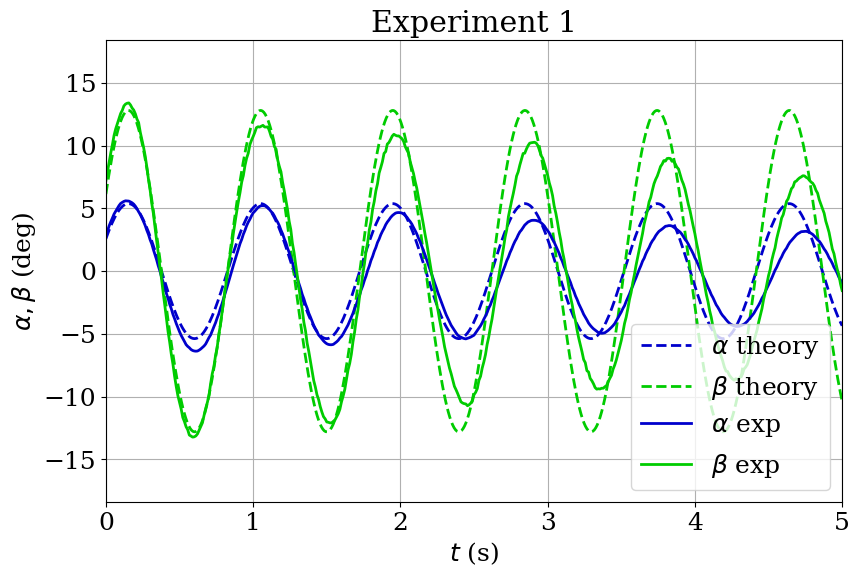

In [10]:
makeplot(make_theoretical_data(12.8,0,0.5,0),Experiment_1)

Now do the same for Experiment_2 and Experiment_3.

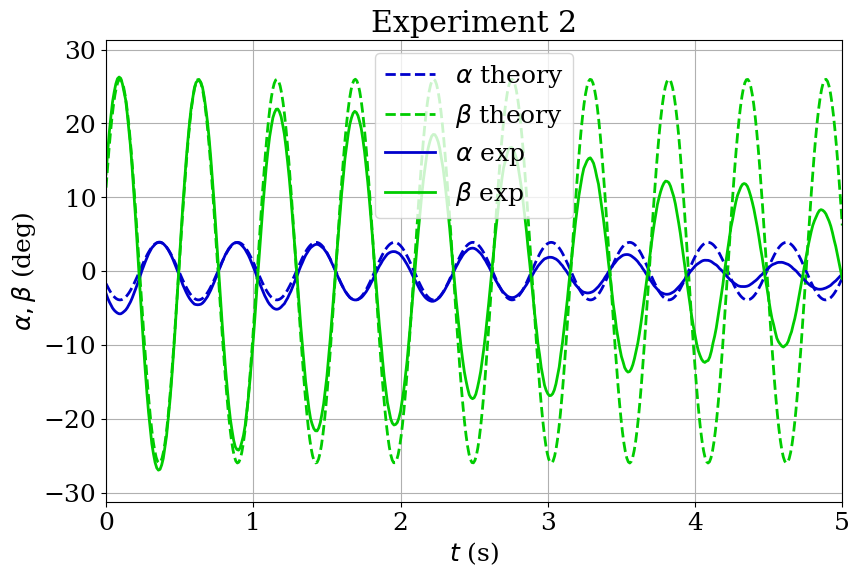

In [11]:
makeplot(make_theoretical_data(0,26,0,0.45),Experiment_2)

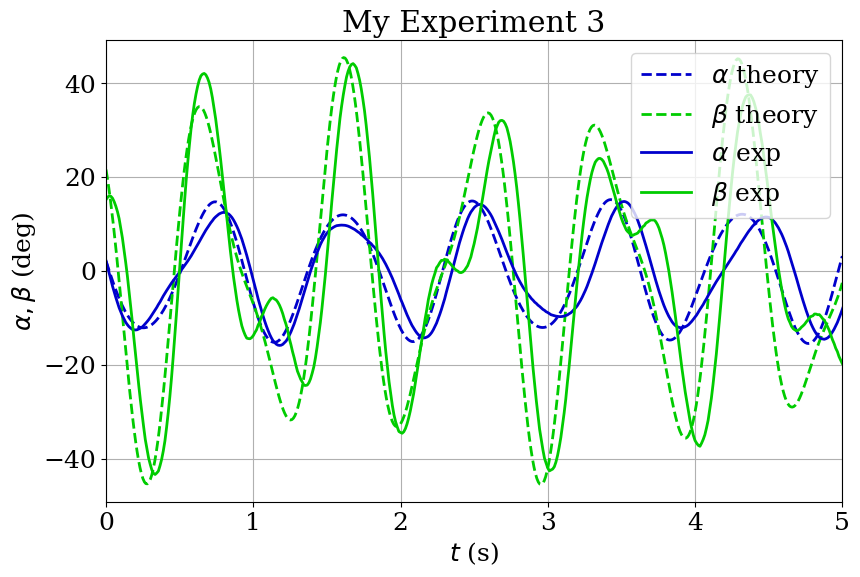

In [36]:
makeplot(make_theoretical_data(33,12.5,2.85,1.33),My_Experiment_3)

A key shortcomming of the theoretical model is that it doesn't account for friction/damping, which is clearly present in the experimental data. Building on last years vibrations course, we should instead try a form like:
$$
\left(\begin{array}{c}
\alpha \\
\beta\end{array}\right)=A_1 \mathrm{e}^{-\gamma_1 t} \left(\begin{array}{c}
ModeShapeRatio_1 \\
1\end{array}\right)\sin{\left(\omega_1 t +\phi_1\right)}+A_2 \mathrm{e}^{-\gamma_2 t} \left(\begin{array}{c}
ModeShapeRatio_2 \\
1\end{array}\right)\sin{\left(\omega_2 t +\phi_2\right)}
$$
where the two modes each decay with a different damping factor $\gamma_1$ and $\gamma_2$. This cell fixes values of $gamma_1$ and $gamma_2$, and then defines a new function

make_theoretical_data_with_damping

which is exactly like make_theoretical_data except it also includes this damping. [FILL IN THE GAPS, perhaps start with gamma1=gamma2=0.5]


In [29]:
gamma1=0.06 #1/seconds
gamma2=0.15 #1/seconds

def make_theoretical_data_with_damping(A1,A2,phi1,phi2):
    t = np.linspace(0,5,500)
    alpha=A1*mode1shaperatio*np.sin(omega1*t+phi1)*np.exp(-gamma1*t)+A2*mode2shaperatio*np.sin(omega2*t+phi2)*np.exp(-gamma2*t)
    beta=A1*np.sin(omega1*t+phi1)*np.exp(-gamma1*t)+A2*np.sin(omega2*t+phi2)*np.exp(-gamma2*t)
    return [t,alpha,beta]

Now plot the damped prediction against the experimental data, and fiddle with all the parameters to get the best fit you can. See if you can find one set of parameters that fit all three experiments well.


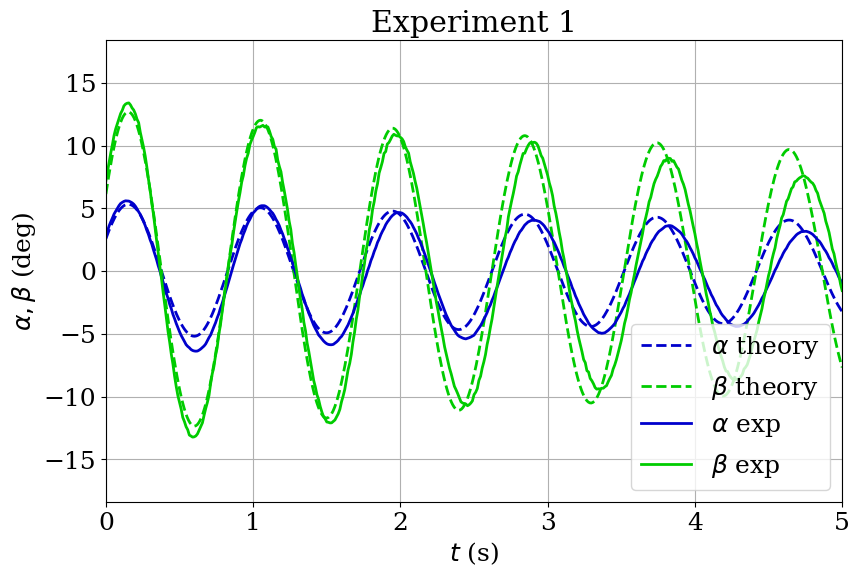

In [30]:
makeplot(make_theoretical_data_with_damping(12.8,0,0.5,0),Experiment_1)

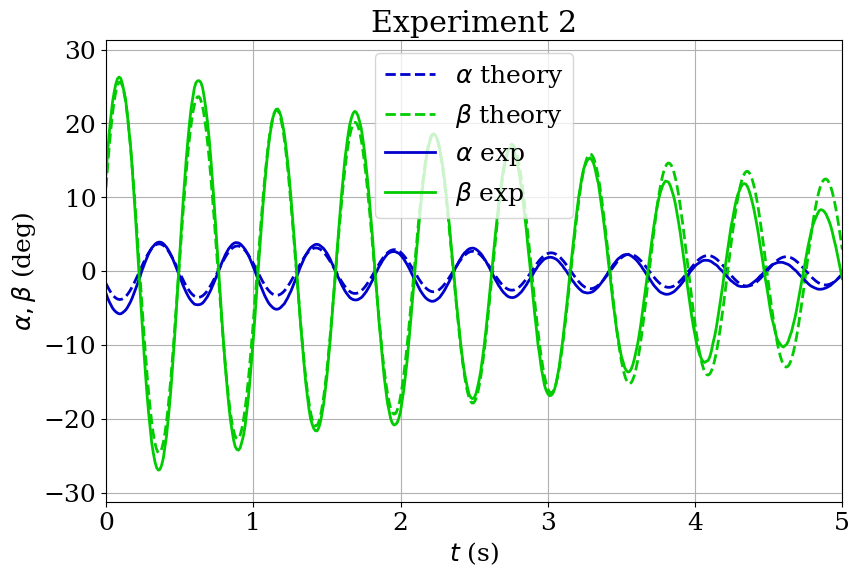

In [31]:
makeplot(make_theoretical_data_with_damping(0,26,0,0.45),Experiment_2)

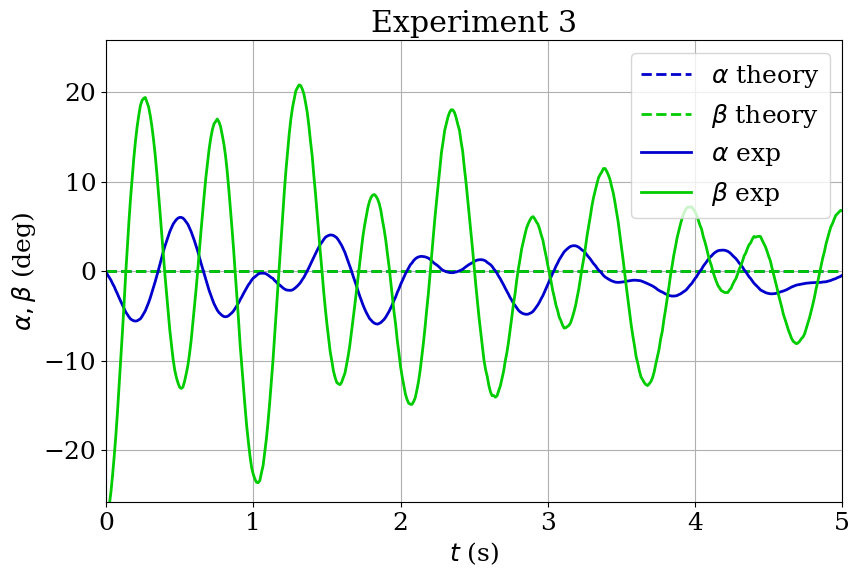

In [34]:
makeplot(make_theoretical_data_with_damping(0,0,0,0),Experiment_3)

Now try your own small vibrations data! The cell below makes the first plot for your 1-page submission for D1 lab credit. Try to find some theory parameters that give a good fit - you may wish to re-analyze your own versions of Exp_1 and Exp_2 to find your best values of omega1, omega2, mode1shaperatio, mode2shaperatio - these can drift a little between experiments.

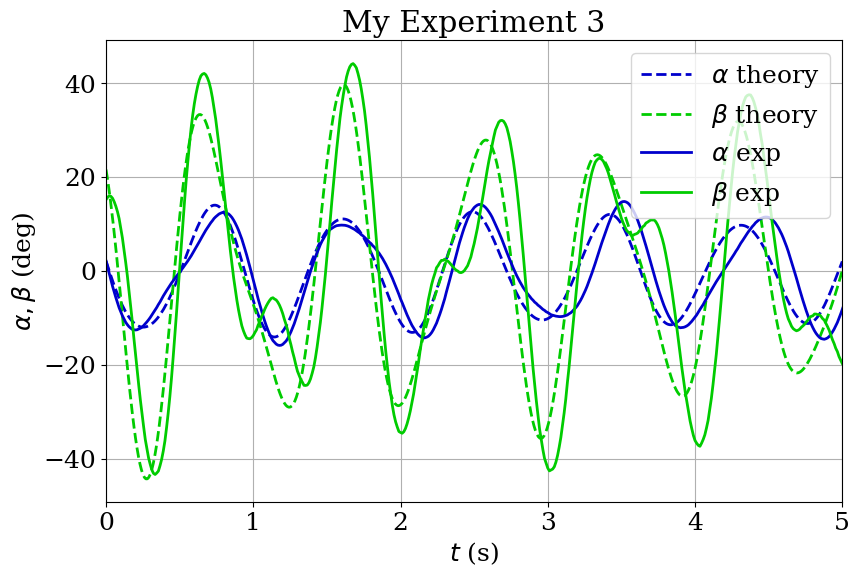

In [37]:
makeplot(make_theoretical_data_with_damping(33,12.5,2.85,1.33),My_Experiment_3)

Take the My_Experiment_3 plot in the cell above for your report. In a web browswer, you can save the image by simply right clicking on it. Don't forget to also make a note of the theoretical parameters, omega1, omega2, mode1shaperatio, mode2shaperatio, A1, A2, phi1, phi2, gamma1, gamma2